In [1]:

import subprocess
import sys

def install_if_missing(package):
    try:
        __import__(package.split('[')[0])
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing("dynamax")
install_if_missing("tensorboard")
install_if_missing("scipy")
install_if_missing("protobuf")

import jax
import jax.numpy as jnp
from jax import random, vmap, jit, grad
from jax.extend import backend as jax_backend
from jax.flatten_util import ravel_pytree
import flax.linen as nn
from flax import nnx
from flax.training import train_state
import optax
import numpy as np
from typing import List, Tuple, Dict, Any, Optional
from functools import partial
from dataclasses import dataclass, field
import time
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist as tf_mnist
from torch.utils.tensorboard import SummaryWriter
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
import pickle
import os

print("All packages imported successfully!")

Installing dynamax...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.1/157.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.8 MB/s eta 0:00:00
Installing protobuf...


2025-11-29 04:54:33.958934: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764392074.155472     108 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764392074.211739     108 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

All packages imported successfully!


Backend: GPU
Devices: 1
  [0] Tesla P100-PCIE-16GB: cuda:0

 GPU acceleration enabled
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32

Domain shift applied: both (angle=45.0°)


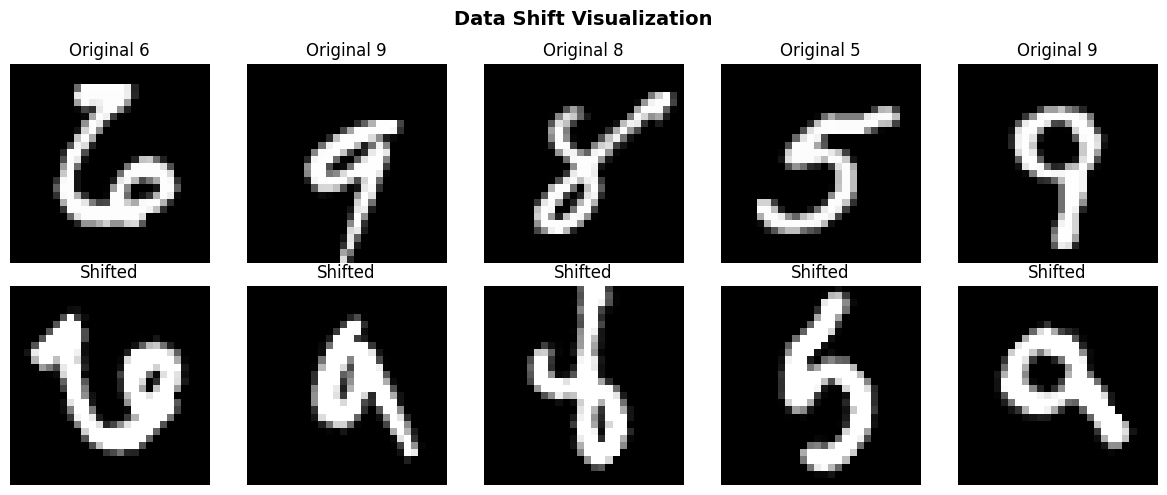

Domain shift visualization saved


In [2]:

@dataclass
class Config:
    # Data
    n_train_samples: int = 10000
    n_test_samples: int = 2000
    batch_size: int = 128

    # Domain Shift
    shift_type: str = 'both'  # 'rotation', 'brightness_contrast', or 'both'
    rotation_angle: float = 45.0
    contrast: float = 1.8
    brightness: float = 0.4

    # Model
    hidden_sizes: List[int] = field(default_factory=lambda: [128])
    num_classes: int = 10
    dropout_rate: float = 0.1

    # Training - PRETRAIN
    pretrain_epochs: int = 10
    pretrain_lr: float = 1e-4

    # Fine Tuning
    adam_epochs: int = 100
    ekf_epochs: int = 1
    dekf_epochs: int = 1
    lora_epochs: int = 30
    lora_ekf_epochs: int = 1
    lora_dekf_epochs: int = 1

    # Learning rates
    finetune_lr: float = 1e-3        # For Adam
    lora_finetune_lr: float = 5e-3   # For LoRA

    # DEKF/EKF
    prior_variance: float = 0.1
    dynamics_sigma: float = 1e-6
    observation_noise: float = 1e-3

    # LoRA
    lora_rank: int = 7
    lora_alpha: float = 14.0

    # Logging and Checkpointing
    print_batch_metrics: bool = False
    checkpoint_metric: str = 'test_acc'  # 'test_acc' or 'test_loss'
    checkpoint_dir: str = '/mnt/user-data/outputs/checkpoints'
    verify_covariance: bool = True

    seed: int = 42

config = Config()
os.makedirs(config.checkpoint_dir, exist_ok=True)

# Device Setup
def setup_device():
    devices = jax.devices()
    backend = jax_backend.get_backend().platform
    print(f"Backend: {backend.upper()}")
    print(f"Devices: {len(devices)}")
    for i, device in enumerate(devices):
        print(f"  [{i}] {device.device_kind}: {device}")
    if backend == 'gpu':
        print(f"\n GPU acceleration enabled")
    elif backend == 'tpu':
        print(f"\n TPU acceleration enabled")
    else:
        print(f"\n CPU only")
    print("="*80)
    return devices[0], backend

device, backend = setup_device()

# DATA LOADING AND DOMAIN SHIFT

def load_mnist(normalize=True, n_train_samples=None, n_test_samples=None):
    n_train_samples = n_train_samples or config.n_train_samples
    n_test_samples = n_test_samples or config.n_test_samples

    (X_train, y_train), (X_test, y_test) = tf_mnist.load_data()

    if normalize:
        X_train = X_train.astype(np.float32) / 255.0
        X_test = X_test.astype(np.float32) / 255.0

    X_train = X_train.reshape(-1, 28*28)
    X_test = X_test.reshape(-1, 28*28)

    # Subsample
    rng = np.random.RandomState(config.seed)
    train_idx = rng.choice(len(X_train), n_train_samples, replace=False)
    test_idx = rng.choice(len(X_test), n_test_samples, replace=False)

    X_train = X_train[train_idx]
    y_train = y_train[train_idx]
    X_test = X_test[test_idx]
    y_test = y_test[test_idx]

    X_train = jnp.array(X_train, dtype=jnp.float32)
    X_test = jnp.array(X_test, dtype=jnp.float32)
    y_train = jnp.array(y_train, dtype=jnp.int32)
    y_test = jnp.array(y_test, dtype=jnp.int32)

    print(f"Data loaded:")
    print(f"  Train: {X_train.shape}, dtype={X_train.dtype}")
    print(f"  Test: {X_test.shape}, dtype={X_test.dtype}")

    return X_train, y_train, X_test, y_test

def apply_domain_shift(X, shift_type='brightness_contrast', contrast=1.8, brightness=0.4, rotation_angle=45):
    X_reshaped = X.reshape(-1, 28, 28)

    if shift_type == 'brightness_contrast':
        X_shifted = np.clip(((X_reshaped - 0.5) * contrast + 0.5) + brightness, 0, 1)
    elif shift_type == 'rotation':
        from scipy.ndimage import rotate
        X_shifted = np.array([rotate(img, rotation_angle, reshape=False, order=1, mode='constant', cval=0.0)
                             for img in X_reshaped])
    elif shift_type == 'both':
        from scipy.ndimage import rotate
        X_rotated = np.array([rotate(img, rotation_angle, reshape=False, order=1, mode='constant', cval=0.0)
                             for img in X_reshaped])
        X_shifted = np.clip(((X_rotated - 0.5) * contrast + 0.5) + brightness, 0, 1)
    else:
        X_shifted = X_reshaped

    X_shifted = X_shifted.reshape(-1, 28*28)
    return jnp.array(X_shifted, dtype=jnp.float32)

# Load data
X_train, y_train, X_test, y_test = load_mnist()

# Apply domain shift
X_train_shifted = apply_domain_shift(X_train, shift_type=config.shift_type,
                                     rotation_angle=config.rotation_angle,
                                     contrast=config.contrast,
                                     brightness=config.brightness)
X_test_shifted = apply_domain_shift(X_test, shift_type=config.shift_type,
                                    rotation_angle=config.rotation_angle,
                                    contrast=config.contrast,
                                    brightness=config.brightness)

print(f"\nDomain shift applied: {config.shift_type} (angle={config.rotation_angle}°)")

# Visualize domain shift
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Original {y_test[i]}')

    axes[1, i].imshow(X_test_shifted[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Shifted')

plt.suptitle('Data Shift Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/domain_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Domain shift visualization saved")

In [3]:

class MLP(nnx.Module):
    def __init__(self, hidden_sizes: List[int], num_classes: int, rngs: nnx.Rngs):
        self.hidden_sizes = hidden_sizes
        self.num_classes = num_classes
        self.layers = []
        in_features = 28 * 28
        for i, hidden_size in enumerate(hidden_sizes):
            self.layers.append(nnx.Linear(in_features, hidden_size, rngs=rngs))
            in_features = hidden_size
        self.output = nnx.Linear(in_features, num_classes, rngs=rngs)
        self.dropout = nnx.Dropout(rate=config.dropout_rate, rngs=rngs)

    def __call__(self, x, training: bool = False):
        for layer in self.layers:
            x = layer(x)
            x = nnx.relu(x)
            if training:
                x = self.dropout(x)
        return self.output(x)

    def extract_features(self, x):
        for layer in self.layers:
            x = layer(x)
            x = nnx.relu(x)
        return x

# Loss and Metrics
@jit
def cross_entropy_loss(logits, labels):
    one_hot = jax.nn.one_hot(labels, config.num_classes)
    return -jnp.mean(jnp.sum(one_hot * jax.nn.log_softmax(logits), axis=-1)) # axis = -1 is the num classes

@jit
def compute_accuracy(logits, labels):
    predictions = jnp.argmax(logits, axis=-1)
    return jnp.mean(predictions == labels)

# Covariance Verification
def verify_covariance_matrix(P, name="P", step=0):
    if not config.verify_covariance:
        return

    is_symmetric = jnp.allclose(P, P.T, atol=1e-6) 

    eigenvalues = jnp.linalg.eigvalsh(P)

    min_eigenvalue = jnp.min(eigenvalues)
    is_psd = min_eigenvalue >= -1e-6
    trace = jnp.trace(P) 
    frobenius_norm = jnp.linalg.norm(P, 'fro')

    if step % 50 == 0:
        print(f"    [{name} @step {step}] Symmetric: {is_symmetric}, PSD: {is_psd}, "
              f"Tr: {trace:.2e}, ||P||_F: {frobenius_norm:.2e}, λ_min: {min_eigenvalue:.2e}")

    if not is_symmetric:
        print(f"    WARNING: {name} is not symmetric at step {step}!")
    if not is_psd:
        print(f"    WARNING: {name} is not PSD at step {step}! Min eigenvalue: {min_eigenvalue:.2e}")

def compare_covariances(P_prev, P_curr, name="P", step=0):
    if not config.verify_covariance or P_prev is None:
        return

    diff_norm = jnp.linalg.norm(P_curr - P_prev, 'fro')
    relative_change = diff_norm / (jnp.linalg.norm(P_prev, 'fro') + 1e-10)

    if step % 50 == 0:
        print(f"    [{name} @step {step}] ||P_curr - P_prev||_F: {diff_norm:.2e}, "
              f"Relative change: {relative_change:.4f}")

print("Model and utilities defined")

Model and utilities defined


In [4]:
# PRETRAINING SETUP

#Convert a Flax NNX model into a TrainState object for JAX-style functional training.
class TrainState(train_state.TrainState):
    graphdef: Any = None
    output_graphdef: Any = None
    full_other_states: Any = None
    output_other_states: Any = None

def create_train_state(model, learning_rate):
    """Create train state for FULL model (all parameters)"""
    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    tx = optax.adam(learning_rate)
    def apply_fn(params, x, training=False):
        model_copy = nnx.merge(graphdef, params, other_states)
        return model_copy(x, training=training)
    return TrainState.create(
        apply_fn=apply_fn,
        params=params,
        tx=tx,
        graphdef=graphdef
    )

def create_output_only_train_state(model, learning_rate):
    """Create train state for LAST LAYER ONLY"""
    output_layer = model.output
    output_graphdef, output_params, output_other_states = nnx.split(output_layer, nnx.Param, ...)

    full_graphdef, full_params, full_other_states = nnx.split(model, nnx.Param, ...)

    tx = optax.adam(learning_rate)

    # OLD: This closure captured stale full_other_states
    # def apply_fn(output_params, x, training=False):
    #     output_layer_updated = nnx.merge(output_graphdef, output_params, output_other_states)
    #     model_copy = nnx.merge(full_graphdef, full_params, full_other_states)
    #     model_copy.output = output_layer_updated
    #     return model_copy(x, training=training)

    # NEW: Extract features with frozen layers in eval mode to avoid stale dropout
    def apply_fn(output_params, x, training=False):
        # Reconstruct frozen base model
        model_copy = nnx.merge(full_graphdef, full_params, full_other_states)
        # Extract features WITHOUT dropout (eval mode for frozen layers)
        features = model_copy.extract_features(x)
        # Apply trainable output layer
        output_layer_updated = nnx.merge(output_graphdef, output_params, output_other_states)
        logits = output_layer_updated(features)
        return logits

    return TrainState.create(
        apply_fn=apply_fn,
        params=output_params,
        tx=tx,
        graphdef=full_graphdef,
        output_graphdef=output_graphdef,
        full_other_states=full_other_states,
        output_other_states=output_other_states
    )

# For PRETRAINING (with dropout)
@jit
def pretrain_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=True)  # Enable dropout
        return cross_entropy_loss(logits, y)

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)  # Eval mode for metrics
    acc = compute_accuracy(logits, y)
    return state, loss, acc

# For FINE-TUNING (frozen layers, no dropout in base)
@jit
def finetune_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=False)  # Avoid stale dropout
        return cross_entropy_loss(logits, y)

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)
    acc = compute_accuracy(logits, y)
    return state, loss, acc

@jit
def eval_step(state, batch):
    x, y = batch
    logits = state.apply_fn(state.params, x, training=False)
    loss = cross_entropy_loss(logits, y)
    acc = compute_accuracy(logits, y)
    return loss, acc

print("Training utilities defined")

Training utilities defined


In [5]:
# PRETRAINING

writer = SummaryWriter('/mnt/user-data/outputs/runs')

def pretrain_model(X_train, y_train, X_test, y_test, writer=None):
    print("\n" + "="*80)
    print("PRETRAINING")
    print("="*80)

    rng = nnx.Rngs(config.seed)
    model = MLP(config.hidden_sizes, config.num_classes, rng)
    state = create_train_state(model, config.pretrain_lr)

    # OLD: n_batches = len(X_train) // config.batch_size  # Drops last incomplete batch
    # NEW: Include last batch even if incomplete
    n_batches = int(np.ceil(len(X_train) / config.batch_size))

    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + config.seed)
        perm = random.permutation(key, len(X_train))
        X_shuffled = X_train[perm]
        y_shuffled = y_train[perm]

        epoch_loss = 0.0
        epoch_acc = 0.0

        for i in range(n_batches):
            start_idx = i * config.batch_size
            end_idx = min((i + 1) * config.batch_size, len(X_train))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]

            #state, loss, acc = train_step(state, (batch_x, batch_y))
            state, loss, acc = pretrain_step(state, (batch_x, batch_y))
            epoch_loss += loss
            epoch_acc += acc

        epoch_loss /= n_batches
        epoch_acc /= n_batches
        test_loss, test_acc = eval_step(state, (X_test, y_test))

        print(f"Epoch {epoch+1}/{config.pretrain_epochs} | "
              f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

        if writer:
            writer.add_scalar('pretrain/train_loss', float(epoch_loss), epoch)
            writer.add_scalar('pretrain/train_acc', float(epoch_acc), epoch)
            writer.add_scalar('pretrain/test_loss', float(test_loss), epoch)
            writer.add_scalar('pretrain/test_acc', float(test_acc), epoch)

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    final_model = nnx.merge(graphdef, state.params, other_states)
    return final_model, float(test_acc), float(test_loss)

# Run pretraining
pretrained_model, pretrain_acc, pretrain_loss = pretrain_model(
    X_train, y_train, X_test, y_test, writer
)

print(f"\nPretrained model: Acc={pretrain_acc:.4f}, Loss={pretrain_loss:.4f}")

# Evaluate on shifted data (baseline)
test_logits = pretrained_model(X_test_shifted, training=False)
baseline_acc = float(compute_accuracy(test_logits, y_test))
baseline_loss = float(cross_entropy_loss(test_logits, y_test))
print(f"Baseline on shifted data: Acc={baseline_acc:.4f}, Loss={baseline_loss:.4f}")


PRETRAINING
Epoch 1/10 | Train Loss: 2.0199 | Train Acc: 0.4382 | Test Loss: 1.6739 | Test Acc: 0.6990
Epoch 2/10 | Train Loss: 1.4353 | Train Acc: 0.7413 | Test Loss: 1.1496 | Test Acc: 0.8050
Epoch 3/10 | Train Loss: 1.0351 | Train Acc: 0.8140 | Test Loss: 0.8524 | Test Acc: 0.8390
Epoch 4/10 | Train Loss: 0.8104 | Train Acc: 0.8364 | Test Loss: 0.6838 | Test Acc: 0.8645
Epoch 5/10 | Train Loss: 0.6849 | Train Acc: 0.8570 | Test Loss: 0.5824 | Test Acc: 0.8765
Epoch 6/10 | Train Loss: 0.5963 | Train Acc: 0.8706 | Test Loss: 0.5137 | Test Acc: 0.8890
Epoch 7/10 | Train Loss: 0.5351 | Train Acc: 0.8795 | Test Loss: 0.4652 | Test Acc: 0.8925
Epoch 8/10 | Train Loss: 0.4957 | Train Acc: 0.8859 | Test Loss: 0.4275 | Test Acc: 0.8930
Epoch 9/10 | Train Loss: 0.4571 | Train Acc: 0.8931 | Test Loss: 0.3988 | Test Acc: 0.8990
Epoch 10/10 | Train Loss: 0.4364 | Train Acc: 0.8961 | Test Loss: 0.3770 | Test Acc: 0.9035

Pretrained model: Acc=0.9035, Loss=0.3770
Baseline on shifted data: Acc=0.2

In [6]:
# CHECKPOINT UTILITIES

def save_checkpoint(method, model, metrics, covariances=None, epoch=0):
    """Save model checkpoint with covariances for Kalman filters"""
    checkpoint_path = os.path.join(config.checkpoint_dir, f"{method}_best.npz")

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    flat_params, _ = ravel_pytree(params)

    if covariances is not None:
        if isinstance(covariances, dict):
            covariances_np = {k: np.array(v) for k, v in covariances.items()}
        else:
            covariances_np = np.array(covariances)
    else:
        covariances_np = None

    save_dict = {
        'params': np.array(flat_params),
        'metrics_acc': metrics['test_acc'],
        'metrics_loss': metrics['test_loss'],
        'epoch': epoch,
        'method': method
    }

    if covariances_np is not None:
        if isinstance(covariances_np, dict):
            for k, v in covariances_np.items():
                save_dict[f'cov_{k}'] = v
        else:
            save_dict['cov'] = covariances_np

    np.savez(checkpoint_path, **save_dict)

    graphdef_path = os.path.join(config.checkpoint_dir, f"{method}_graphdef.pkl")
    if not os.path.exists(graphdef_path):
        try:
            with open(graphdef_path, 'wb') as f:
                pickle.dump({'graphdef': graphdef, 'other_states': other_states}, f)
        except Exception as e:
            print(f"    Warning: Could not pickle graphdef: {e}")
            with open(graphdef_path, 'wb') as f:
                pickle.dump({'method': method}, f)

    print(f"Checkpoint saved: {checkpoint_path} (epoch {epoch}, {config.checkpoint_metric}={metrics[config.checkpoint_metric]:.4f})")

def load_checkpoint(method, model_template):
    """Load best checkpoint"""
    checkpoint_path = os.path.join(config.checkpoint_dir, f"{method}_best.npz")

    if not os.path.exists(checkpoint_path):
        print(f"No checkpoint found: {checkpoint_path}")
        return None, None

    checkpoint = np.load(checkpoint_path)
    flat_params_np = checkpoint['params']
    flat_params = jnp.array(flat_params_np)

    graphdef, current_params, other_states = nnx.split(model_template, nnx.Param, ...)
    _, unflatten_fn = ravel_pytree(current_params)
    restored_params = unflatten_fn(flat_params)
    model = nnx.merge(graphdef, restored_params, other_states)

    covariances = None
    if 'cov' in checkpoint.files:
        covariances = jnp.array(checkpoint['cov'])
    elif any(f.startswith('cov_') for f in checkpoint.files):
        covariances = {}
        for f in checkpoint.files:
            if f.startswith('cov_'):
                key = f[4:]
                covariances[key] = jnp.array(checkpoint[f])

    epoch = int(checkpoint['epoch'])
    print(f"Checkpoint loaded: {checkpoint_path} (epoch {epoch})")

    return model, covariances

print("Checkpoint utilities defined")

Checkpoint utilities defined


In [7]:
# ADAM FINE-TUNING

print("\n" + "="*80)
print("ADAM FINE-TUNING")
print("="*80)

adam_model = nnx.clone(pretrained_model)
adam_state = create_output_only_train_state(adam_model, config.finetune_lr)
adam_losses, adam_accs = [], []
adam_test_accs_per_epoch = []
adam_test_losses_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')

# OLD: n_batches_per_epoch = len(X_train_shifted) // config.batch_size
# NEW: Include last incomplete batch
n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))

#for epoch in range(config.finetune_epochs):
for epoch in range(config.adam_epochs):
    key = random.PRNGKey(epoch + config.seed + 1000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train[perm]

    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]

        #adam_state, loss, acc = train_step(adam_state, (batch_x, batch_y))
        adam_state, loss, acc = finetune_step(adam_state, (batch_x, batch_y))
        adam_losses.append(float(loss))
        adam_accs.append(float(acc))

        epoch_loss += loss
        epoch_acc += acc

        if config.print_batch_metrics:
            print(f"  Epoch {epoch+1}/{config.adam_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {float(loss):.4f} | Acc: {float(acc):.4f}")

        if writer:
            writer.add_scalar('adam/loss', float(loss), total_steps)
            writer.add_scalar('adam/acc', float(acc), total_steps)

        total_steps += 1

    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch

    # Evaluate
    test_logits = adam_state.apply_fn(adam_state.params, X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test))
    test_loss = float(cross_entropy_loss(test_logits, y_test))

    adam_test_accs_per_epoch.append(test_acc)
    adam_test_losses_per_epoch.append(test_loss)

    print(f"  Epoch {epoch+1}/{config.adam_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        # Reconstruct full model for checkpointing
        output_layer_updated = nnx.merge(adam_state.output_graphdef, adam_state.params, adam_state.output_other_states)
        temp_model = nnx.clone(adam_model)
        temp_model.output = output_layer_updated
        save_checkpoint('adam', temp_model, {'test_acc': test_acc, 'test_loss': test_loss},
                      covariances=None, epoch=epoch)

adam_time = time.time() - start_time

# Load best checkpoint
best_adam_model, _ = load_checkpoint('adam', adam_model)
if best_adam_model is not None:
    adam_model = best_adam_model

# Final evaluation
test_logits = adam_model(X_test_shifted, training=False)
adam_test_acc = float(compute_accuracy(test_logits, y_test))
adam_test_loss = float(cross_entropy_loss(test_logits, y_test))

adam_results = {
    'losses': adam_losses,
    'accs': adam_accs,
    'test_acc': adam_test_acc,
    'test_loss': adam_test_loss,
    'time': adam_time,
    'model': adam_model,
    'test_accs_per_epoch': adam_test_accs_per_epoch,
    'test_losses_per_epoch': adam_test_losses_per_epoch
}

print(f"\nADAM Final: Acc={adam_test_acc:.4f}, Loss={adam_test_loss:.4f}, Time={adam_time:.2f}s")


ADAM FINE-TUNING
  Epoch 1/100 | Train Loss: 1.9411 | Train Acc: 0.3693 | Test Loss: 1.4757 | Test Acc: 0.4725
Checkpoint saved: /mnt/user-data/outputs/checkpoints/adam_best.npz (epoch 0, test_acc=0.4725)
  Epoch 2/100 | Train Loss: 1.2606 | Train Acc: 0.5756 | Test Loss: 1.0574 | Test Acc: 0.6760
Checkpoint saved: /mnt/user-data/outputs/checkpoints/adam_best.npz (epoch 1, test_acc=0.6760)
  Epoch 3/100 | Train Loss: 0.9762 | Train Acc: 0.7066 | Test Loss: 0.8584 | Test Acc: 0.7550
Checkpoint saved: /mnt/user-data/outputs/checkpoints/adam_best.npz (epoch 2, test_acc=0.7550)
  Epoch 4/100 | Train Loss: 0.8343 | Train Acc: 0.7594 | Test Loss: 0.7516 | Test Acc: 0.7870
Checkpoint saved: /mnt/user-data/outputs/checkpoints/adam_best.npz (epoch 3, test_acc=0.7870)
  Epoch 5/100 | Train Loss: 0.7509 | Train Acc: 0.7864 | Test Loss: 0.6839 | Test Acc: 0.8045
Checkpoint saved: /mnt/user-data/outputs/checkpoints/adam_best.npz (epoch 4, test_acc=0.8045)
  Epoch 6/100 | Train Loss: 0.6954 | Train

In [8]:
baseline_check = float(compute_accuracy(pretrained_model(X_test_shifted, training=False), y_test))
print(f"Baseline check: {baseline_check:.4f}")

Baseline check: 0.2905


In [9]:
# EKF SETUP AND UPDATE FUNCTIONS

class ParameterGroup:
    def __init__(self, name, flat_params, unflatten_fn, prior_var, dynamic_sigma):
        self.name = name
        self.flat_params = flat_params
        self.unflatten_fn = unflatten_fn
        self.state_dim = flat_params.size
        self.initial_mean = flat_params
        self.initial_covariance = jnp.eye(self.state_dim) * prior_var
        self.dynamics_function = lambda w, x: w
        self.dynamics_covariance = jnp.eye(self.state_dim) * dynamic_sigma

def ekf_update(model, X_batch, y_batch, P_previous=None, use_full_cov=True, step=0):
    """
    Updates model parameters using Extended Kalman Filter

    Conceptually:
    - Treats parameters as "hidden states"
    - Observations are the labels y_batch
    - Updates parameters based on prediction error
    - Tracks uncertainty in covariance matrix P
    """
    output_layer = model.output
    output_state = nnx.state(output_layer, nnx.Param)

    flat_params, unflatten_fn = ravel_pytree(output_state)
    state_dim = flat_params.size

    def forward_fn(params_flat, x):
        params_unflat = unflatten_fn(params_flat)
        output_graphdef, _, other_states = nnx.split(output_layer, nnx.Param, ...)
        output_layer_temp = nnx.merge(output_graphdef, params_unflat, other_states)
        features = model.extract_features(x)
        logits = output_layer_temp(features)
        return jax.nn.softmax(logits)

    initial_mean = flat_params

    if P_previous is None:
        initial_covariance = jnp.eye(state_dim) * config.prior_variance
        print(f"  [EKF] Initializing covariance: P0 = {config.prior_variance} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_previous
        verify_covariance_matrix(P_previous, "P_prev", step)

    dynamics_function = lambda w, x: w # no params drift
    dynamics_covariance = jnp.eye(state_dim) * config.dynamics_sigma

    def emission_mean_function(w, x):
        return forward_fn(w, x)

    def emission_cov_function(w, x):
        probs = emission_mean_function(w, x)
        return jnp.diag(probs * (1 - probs)) + config.observation_noise * jnp.eye(config.num_classes)

    params = ParamsGGSSM(
        initial_mean=initial_mean,
        initial_covariance=initial_covariance,
        dynamics_function=dynamics_function,
        dynamics_covariance=dynamics_covariance,
        emission_mean_function=emission_mean_function,
        emission_cov_function=emission_cov_function
    )
    # conditional_moments_gaussian_filter uses:
    #   num_timesteps = len(emissions)  --> here len(emissions) == B
    #   lax.scan over jnp.arange(num_timesteps)
    #   inside scan: y = emissions[t]  (shape (D_y,)), u = inputs[t]  (shape (D_x,))
    #
    # Effect: The mini-batch of size B is processed sequentially as T = B time-steps.

    emissions = jax.nn.one_hot(y_batch, config.num_classes)
    inputs = X_batch

    ekf_post = conditional_moments_gaussian_filter(
        params,
        EKFIntegrals(),
        emissions,
        inputs
    )

    updated_params_flat = ekf_post.filtered_means[-1]
    updated_covariance = ekf_post.filtered_covariances[-1]

    verify_covariance_matrix(updated_covariance, "P_updated", step)
    compare_covariances(P_previous, updated_covariance, "P_EKF", step)

    updated_params = unflatten_fn(updated_params_flat)
    nnx.update(output_layer, updated_params)

    return model, updated_covariance

print("EKF update function defined")

EKF update function defined


In [10]:
# EKF FINE-TUNING

print("\n" + "="*80)
print("EKF FINE-TUNING (LAST LAYER ONLY)")
print("="*80)

config.batch_size = 1000
ekf_model = nnx.clone(pretrained_model)
ekf_losses, ekf_accs = [], []
ekf_test_accs_per_epoch = []
ekf_test_losses_per_epoch = []
ekf_traces_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')
P_ekf = None
best_P_ekf = None

n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))

#for epoch in range(config.finetune_epochs):
for epoch in range(config.ekf_epochs):
    key = random.PRNGKey(epoch + config.seed + 2000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train[perm]

    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]

        P_ekf_prev = P_ekf
        ekf_model, P_ekf = ekf_update(ekf_model, batch_x, batch_y, P_ekf, use_full_cov=True, step=total_steps)

        logits = ekf_model(batch_x, training=False)
        loss = float(cross_entropy_loss(logits, batch_y))
        acc = float(compute_accuracy(logits, batch_y))
        ekf_losses.append(loss)
        ekf_accs.append(acc)

        epoch_loss += loss
        epoch_acc += acc

        if config.print_batch_metrics:
            trace_P = float(jnp.trace(P_ekf))
            print(f"  Epoch {epoch+1}/{config.ekf_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {loss:.4f} | Acc: {acc:.4f} | Tr(P): {trace_P:.2e}")

        if writer:
            writer.add_scalar('ekf/loss', loss, total_steps)
            writer.add_scalar('ekf/acc', acc, total_steps)
            writer.add_scalar('ekf/trace_P', float(jnp.trace(P_ekf)), total_steps)

        total_steps += 1

    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch

    # Evaluate
    test_logits = ekf_model(X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test))
    test_loss = float(cross_entropy_loss(test_logits, y_test))

    ekf_test_accs_per_epoch.append(test_acc)
    ekf_test_losses_per_epoch.append(test_loss)
    trace_P = float(jnp.trace(P_ekf))
    ekf_traces_per_epoch.append(trace_P)

    print(f"  Epoch {epoch+1}/{config.ekf_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Tr(P): {trace_P:.2e}")

    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        best_P_ekf = P_ekf
        save_checkpoint('ekf', ekf_model, {'test_acc': test_acc, 'test_loss': test_loss},
                      covariances={'P': P_ekf}, epoch=epoch)

ekf_time = time.time() - start_time

# Load best checkpoint
best_ekf_model, covariances = load_checkpoint('ekf', ekf_model)
if best_ekf_model is not None:
    ekf_model = best_ekf_model
    P_ekf = covariances['P'] if covariances else P_ekf

# Final evaluation
test_logits = ekf_model(X_test_shifted, training=False)
ekf_test_acc = float(compute_accuracy(test_logits, y_test))
ekf_test_loss = float(cross_entropy_loss(test_logits, y_test))

ekf_results = {
    'losses': ekf_losses,
    'accs': ekf_accs,
    'test_acc': ekf_test_acc,
    'test_loss': ekf_test_loss,
    'time': ekf_time,
    'model': ekf_model,
    'covariance': P_ekf,
    'test_accs_per_epoch': ekf_test_accs_per_epoch,
    'test_losses_per_epoch': ekf_test_losses_per_epoch,
    'traces_per_epoch': ekf_traces_per_epoch
}

print(f"\nEKF Final: Acc={ekf_test_acc:.4f}, Loss={ekf_test_loss:.4f}, Time={ekf_time:.2f}s")


EKF FINE-TUNING (LAST LAYER ONLY)
  [EKF] Initializing covariance: P0 = 0.1 × I (1290×1290)
    [P_updated @step 0] Symmetric: True, PSD: True, Tr: 1.07e+02, ||P||_F: 3.12e+00, λ_min: 2.86e-04
  Epoch 1/1 | Train Loss: 0.3229 | Train Acc: 0.9208 | Test Loss: 0.2912 | Test Acc: 0.9165 | Tr(P): 8.37e+01
Checkpoint saved: /mnt/user-data/outputs/checkpoints/ekf_best.npz (epoch 0, test_acc=0.9165)
Checkpoint loaded: /mnt/user-data/outputs/checkpoints/ekf_best.npz (epoch 0)

EKF Final: Acc=0.9165, Loss=0.2912, Time=33.54s


In [11]:
baseline_check = float(compute_accuracy(pretrained_model(X_test_shifted, training=False), y_test))
print(f"Baseline check: {baseline_check:.4f}")

Baseline check: 0.2905


In [12]:

def create_lora_model(base_model, rank, alpha):
    """Apply native Flax NNX LoRA to ONLY the output layer"""
    rng = nnx.Rngs(config.seed + 1)

    lora_model = nnx.clone(base_model)

    in_features = base_model.output.in_features
    out_features = base_model.output.out_features

    original_kernel = base_model.output.kernel.value
    original_bias = base_model.output.bias.value

    lora_layer = nnx.LoRALinear(
        in_features=in_features,
        out_features=out_features,
        lora_rank=rank,
        rngs=rng
    )

    # Copy pretrained weights
    lora_layer.kernel.value = original_kernel
    lora_layer.bias.value = original_bias

    # Apply alpha scaling (stored for reference)
    lora_layer.lora_scale = alpha / rank

    lora_model.output = lora_layer

    print(f"  LoRA layer initialized with pretrained weights")
    print(f"  LoRA scaling factor: {alpha}/{rank} = {alpha/rank:.4f}")

    return lora_model


# LORA FINE-TUNING

print("\n" + "="*80)
print("LORA FINE-TUNING (LAST LAYER ONLY, NATIVE NNX)")
print("="*80)

lora_model = create_lora_model(pretrained_model, config.lora_rank, config.lora_alpha)

print(f"  LoRA configuration: rank={config.lora_rank}, alpha={config.lora_alpha}")

# Get all LoRA-specific trainable parameters
def is_lora_trainable(path, value):
    path_str = '/'.join(str(p) for p in path)
    # Include LoRA-specific parameters
    if 'lora' in path_str.lower():
        return True
    # Include output layer bias
    if 'output' in path_str and 'bias' in path_str:
        return True
    return False

# Split to get trainable params
graphdef, trainable_params, frozen_params = nnx.split(lora_model, is_lora_trainable, ...)

# Count parameters
def count_params(pytree):
    return sum(v.value.size if hasattr(v, 'value') else v.size
               for v in jax.tree.leaves(pytree))

all_state = nnx.state(lora_model, nnx.Param)
lora_count = count_params(trainable_params)
all_count = sum(v.size for v in jax.tree.leaves(all_state))

print(f"  LoRA trainable params: {lora_count:,}")
print(f"  Total params: {all_count:,}")
print(f"  LoRA efficiency: {100 * lora_count / all_count:.2f}%")

lora_losses, lora_accs = [], []
lora_test_accs_per_epoch = []
lora_test_losses_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')

config.batch_size = 128
n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))

# Create optimizer
tx = optax.adam(config.lora_finetune_lr)
opt_state = tx.init(trainable_params)

# JIT-compiled training step
@jit
def lora_train_step_jitted(graphdef, trainable_params, frozen_params, opt_state, batch):
    x, y = batch

    def loss_fn(current_trainable_params):
        model_temp = nnx.merge(graphdef, current_trainable_params, frozen_params)
        logits = model_temp(x, training=False)
        return cross_entropy_loss(logits, y)

    # Compute loss and gradients
    loss, grads = jax.value_and_grad(loss_fn)(trainable_params)

    # Update trainable params
    updates, new_opt_state = tx.update(grads, opt_state, trainable_params)
    new_trainable_params = optax.apply_updates(trainable_params, updates)

    # Compute accuracy
    model_acc = nnx.merge(graphdef, new_trainable_params, frozen_params)
    logits_acc = model_acc(x, training=False)
    acc = compute_accuracy(logits_acc, y)

    return new_trainable_params, new_opt_state, loss, acc

print("  JIT-compiled LoRA training step defined")

#for epoch in range(config.finetune_epochs):
for epoch in range(config.lora_epochs):
    key = random.PRNGKey(epoch + config.seed + 4000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train[perm]

    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]

        trainable_params, opt_state, loss, acc = lora_train_step_jitted(
            graphdef, trainable_params, frozen_params, opt_state, (batch_x, batch_y)
        )

        lora_losses.append(float(loss))
        lora_accs.append(float(acc))

        epoch_loss += loss
        epoch_acc += acc

        if config.print_batch_metrics:
            print(f"  Epoch {epoch+1}/{config.lora_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {float(loss):.4f} | Acc: {float(acc):.4f}")

        if writer:
            writer.add_scalar('lora/loss', float(loss), total_steps)
            writer.add_scalar('lora/acc', float(acc), total_steps)

        total_steps += 1

    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch

    # FIX: Update model with state dictionary, not merged model object
    # OLD: nnx.update(lora_model, nnx.merge(graphdef, trainable_params, frozen_params))
    # NEW: Merge trainable and frozen params into a state dict first
    updated_state = nnx.State.merge(trainable_params, frozen_params)
    nnx.update(lora_model, updated_state)

    # Evaluate
    test_logits = lora_model(X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test))
    test_loss = float(cross_entropy_loss(test_logits, y_test))

    lora_test_accs_per_epoch.append(test_acc)
    lora_test_losses_per_epoch.append(test_loss)

    print(f"  Epoch {epoch+1}/{config.lora_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        save_checkpoint('lora', lora_model, {'test_acc': test_acc, 'test_loss': test_loss},
                      covariances=None, epoch=epoch)

lora_time = time.time() - start_time

# Load best checkpoint
best_lora_model, _ = load_checkpoint('lora', lora_model)
if best_lora_model is not None:
    lora_model = best_lora_model

# Final evaluation
test_logits = lora_model(X_test_shifted, training=False)
lora_test_acc = float(compute_accuracy(test_logits, y_test))
lora_test_loss = float(cross_entropy_loss(test_logits, y_test))

lora_results = {
    'losses': lora_losses,
    'accs': lora_accs,
    'test_acc': lora_test_acc,
    'test_loss': lora_test_loss,
    'time': lora_time,
    'model': lora_model,
    'test_accs_per_epoch': lora_test_accs_per_epoch,
    'test_losses_per_epoch': lora_test_losses_per_epoch
}

print(f"\nLoRA Final: Acc={lora_test_acc:.4f}, Loss={lora_test_loss:.4f}, Time={lora_time:.2f}s")


LORA FINE-TUNING (LAST LAYER ONLY, NATIVE NNX)
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 14.0/7 = 2.0000
  LoRA configuration: rank=7, alpha=14.0
  LoRA trainable params: 976
  Total params: 102,736
  LoRA efficiency: 0.95%
  JIT-compiled LoRA training step defined
  Epoch 1/30 | Train Loss: 1.6194 | Train Acc: 0.4960 | Test Loss: 1.0058 | Test Acc: 0.6905
Checkpoint saved: /mnt/user-data/outputs/checkpoints/lora_best.npz (epoch 0, test_acc=0.6905)
  Epoch 2/30 | Train Loss: 0.8566 | Train Acc: 0.7303 | Test Loss: 0.7116 | Test Acc: 0.7795
Checkpoint saved: /mnt/user-data/outputs/checkpoints/lora_best.npz (epoch 1, test_acc=0.7795)
  Epoch 3/30 | Train Loss: 0.6618 | Train Acc: 0.7969 | Test Loss: 0.5781 | Test Acc: 0.8185
Checkpoint saved: /mnt/user-data/outputs/checkpoints/lora_best.npz (epoch 2, test_acc=0.8185)
  Epoch 4/30 | Train Loss: 0.5620 | Train Acc: 0.8307 | Test Loss: 0.5051 | Test Acc: 0.8360
Checkpoint saved: /mnt/user-data/outputs/checkpoi

In [13]:
baseline_check = float(compute_accuracy(pretrained_model(X_test_shifted, training=False), y_test))
print(f"Baseline check: {baseline_check:.4f}")

Baseline check: 0.2905


In [14]:
# LORA-EKF: Full EKF on LoRA Parameters

def lora_ekf_update(model, X_batch, y_batch, P_previous=None, step=0):
    """
    Run full EKF on LoRA parameters only
    Base kernel remains frozen
    """
    output_layer = model.output

    # Get LoRA state using nnx.state
    output_state = nnx.state(output_layer, nnx.Param)

    trainable_dict = {}

    # Get LoRA parameters from nested structure
    if 'lora' in output_state:
        trainable_dict['lora'] = output_state['lora']

    # Get bias
    if 'bias' in output_state:
        trainable_dict['bias'] = output_state['bias']

    # Flatten trainable params
    flat_params, unflatten_fn = ravel_pytree(trainable_dict)
    state_dim = flat_params.size

    if step == 0:
        print(f"  [LoRA-EKF] Trainable params: {state_dim} parameters")
        print(f"  [LoRA-EKF] Keys: {list(trainable_dict.keys())}")

    # Store frozen kernel
    frozen_kernel = output_state['kernel']

    def forward_fn(params_flat, x):
        # Unflatten trainable params
        params = unflatten_fn(params_flat)

        # Reconstruct full state: frozen kernel + trainable LoRA + bias
        temp_state = {'kernel': frozen_kernel}
        temp_state.update(params)

        # Merge back into output layer
        output_graphdef, _, other_states = nnx.split(output_layer, nnx.Param, ...)
        output_layer_temp = nnx.merge(output_graphdef, temp_state, other_states)

        # Forward pass
        features = model.extract_features(x)
        logits = output_layer_temp(features)

        return jax.nn.softmax(logits)

    initial_mean = flat_params

    if P_previous is None:
        initial_covariance = jnp.eye(state_dim) * config.prior_variance
        print(f"  [LoRA-EKF] Initializing covariance: P0 = {config.prior_variance} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_previous
        if step % 50 == 0:
            verify_covariance_matrix(P_previous, "P_lora_prev", step)

    dynamics_function = lambda w, x: w
    dynamics_covariance = jnp.eye(state_dim) * config.dynamics_sigma

    def emission_mean_function(w, x):
        return forward_fn(w, x)

    def emission_cov_function(w, x):
        probs = emission_mean_function(w, x)
        return jnp.diag(probs * (1 - probs)) + config.observation_noise * jnp.eye(config.num_classes)

    params = ParamsGGSSM(
        initial_mean=initial_mean,
        initial_covariance=initial_covariance,
        dynamics_function=dynamics_function,
        dynamics_covariance=dynamics_covariance,
        emission_mean_function=emission_mean_function,
        emission_cov_function=emission_cov_function
    )

    emissions = jax.nn.one_hot(y_batch, config.num_classes)
    inputs = X_batch

    ekf_post = conditional_moments_gaussian_filter(
        params,
        EKFIntegrals(),
        emissions,
        inputs
    )

    updated_params_flat = ekf_post.filtered_means[-1]
    updated_covariance = ekf_post.filtered_covariances[-1]

    if step % 50 == 0:
        verify_covariance_matrix(updated_covariance, "P_lora_updated", step)
        compare_covariances(P_previous, updated_covariance, "P_LoRA", step)

    # Update model with new parameters
    updated_params = unflatten_fn(updated_params_flat)

    # Update using nnx.update
    nnx.update(output_layer, updated_params)

    return model, updated_covariance

print("LoRA-EKF update function defined")

LoRA-EKF update function defined


In [15]:
# LORA-EKF FINE-TUNING

print("\n" + "="*80)
print("LORA-EKF FINE-TUNING")
print("="*80)

# Create LoRA model
lora_ekf_model = create_lora_model(pretrained_model, config.lora_rank, config.lora_alpha)

lora_ekf_losses, lora_ekf_accs = [], []
lora_ekf_test_accs_per_epoch = []
lora_ekf_test_losses_per_epoch = []
lora_ekf_traces_per_epoch = []

start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')

P_lora_ekf = None
best_P_lora_ekf = None

config.batch_size = 1000
n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))

#for epoch in range(config.finetune_epochs):
for epoch in range(config.lora_ekf_epochs):
    key = random.PRNGKey(epoch + config.seed + 6000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train[perm]

    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]

        P_lora_ekf_prev = P_lora_ekf

        lora_ekf_model, P_lora_ekf = lora_ekf_update(
            lora_ekf_model, batch_x, batch_y, P_lora_ekf, step=total_steps
        )

        logits = lora_ekf_model(batch_x, training=False)
        loss = float(cross_entropy_loss(logits, batch_y))
        acc = float(compute_accuracy(logits, batch_y))
        lora_ekf_losses.append(loss)
        lora_ekf_accs.append(acc)

        epoch_loss += loss
        epoch_acc += acc

        if config.print_batch_metrics:
            trace_P = float(jnp.trace(P_lora_ekf))
            print(f"  Epoch {epoch+1}/{config.lora_ekf_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {loss:.4f} | Acc: {acc:.4f} | Tr(P): {trace_P:.2e}")

        if writer:
            writer.add_scalar('lora_ekf/loss', loss, total_steps)
            writer.add_scalar('lora_ekf/acc', acc, total_steps)
            writer.add_scalar('lora_ekf/trace_P', float(jnp.trace(P_lora_ekf)), total_steps)

        total_steps += 1

    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch

    # Evaluate
    test_logits = lora_ekf_model(X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test))
    test_loss = float(cross_entropy_loss(test_logits, y_test))

    lora_ekf_test_accs_per_epoch.append(test_acc)
    lora_ekf_test_losses_per_epoch.append(test_loss)
    trace_P = float(jnp.trace(P_lora_ekf))
    lora_ekf_traces_per_epoch.append(trace_P)

    print(f"  Epoch {epoch+1}/{config.lora_ekf_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Tr(P): {trace_P:.2e}")

    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        best_P_lora_ekf = P_lora_ekf
        save_checkpoint('lora_ekf', lora_ekf_model, {'test_acc': test_acc, 'test_loss': test_loss},
                      covariances={'P': P_lora_ekf}, epoch=epoch)

lora_ekf_time = time.time() - start_time

# Load best checkpoint
best_lora_ekf_model, covariances = load_checkpoint('lora_ekf', lora_ekf_model)
if best_lora_ekf_model is not None:
    lora_ekf_model = best_lora_ekf_model
    P_lora_ekf = covariances.get('P', P_lora_ekf) if covariances else P_lora_ekf

# Final evaluation
test_logits = lora_ekf_model(X_test_shifted, training=False)
lora_ekf_test_acc = float(compute_accuracy(test_logits, y_test))
lora_ekf_test_loss = float(cross_entropy_loss(test_logits, y_test))

lora_ekf_results = {
    'losses': lora_ekf_losses,
    'accs': lora_ekf_accs,
    'test_acc': lora_ekf_test_acc,
    'test_loss': lora_ekf_test_loss,
    'time': lora_ekf_time,
    'model': lora_ekf_model,
    'covariance': P_lora_ekf,
    'test_accs_per_epoch': lora_ekf_test_accs_per_epoch,
    'test_losses_per_epoch': lora_ekf_test_losses_per_epoch,
    'traces_per_epoch': lora_ekf_traces_per_epoch
}

print(f"\nLoRA-EKF Final: Acc={lora_ekf_test_acc:.4f}, Loss={lora_ekf_test_loss:.4f}, Time={lora_ekf_time:.2f}s")


LORA-EKF FINE-TUNING
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 14.0/7 = 2.0000
  [LoRA-EKF] Trainable params: 976 parameters
  [LoRA-EKF] Keys: ['lora', 'bias']
  [LoRA-EKF] Initializing covariance: P0 = 0.1 × I (976×976)
    [P_lora_updated @step 0] Symmetric: True, PSD: True, Tr: 7.58e+01, ||P||_F: 2.59e+00, λ_min: 2.48e-04
  Epoch 1/1 | Train Loss: 0.3073 | Train Acc: 0.9197 | Test Loss: 0.2943 | Test Acc: 0.9145 | Tr(P): 4.36e+01
Checkpoint saved: /mnt/user-data/outputs/checkpoints/lora_ekf_best.npz (epoch 0, test_acc=0.9145)
Checkpoint loaded: /mnt/user-data/outputs/checkpoints/lora_ekf_best.npz (epoch 0)

LoRA-EKF Final: Acc=0.9145, Loss=0.2943, Time=19.83s


ADAM: 1,290 trainable parameters
EKF: 1,290 trainable parameters
LORA: 976 trainable parameters
LORA_EKF: 976 trainable parameters

Comprehensive results v2 saved!


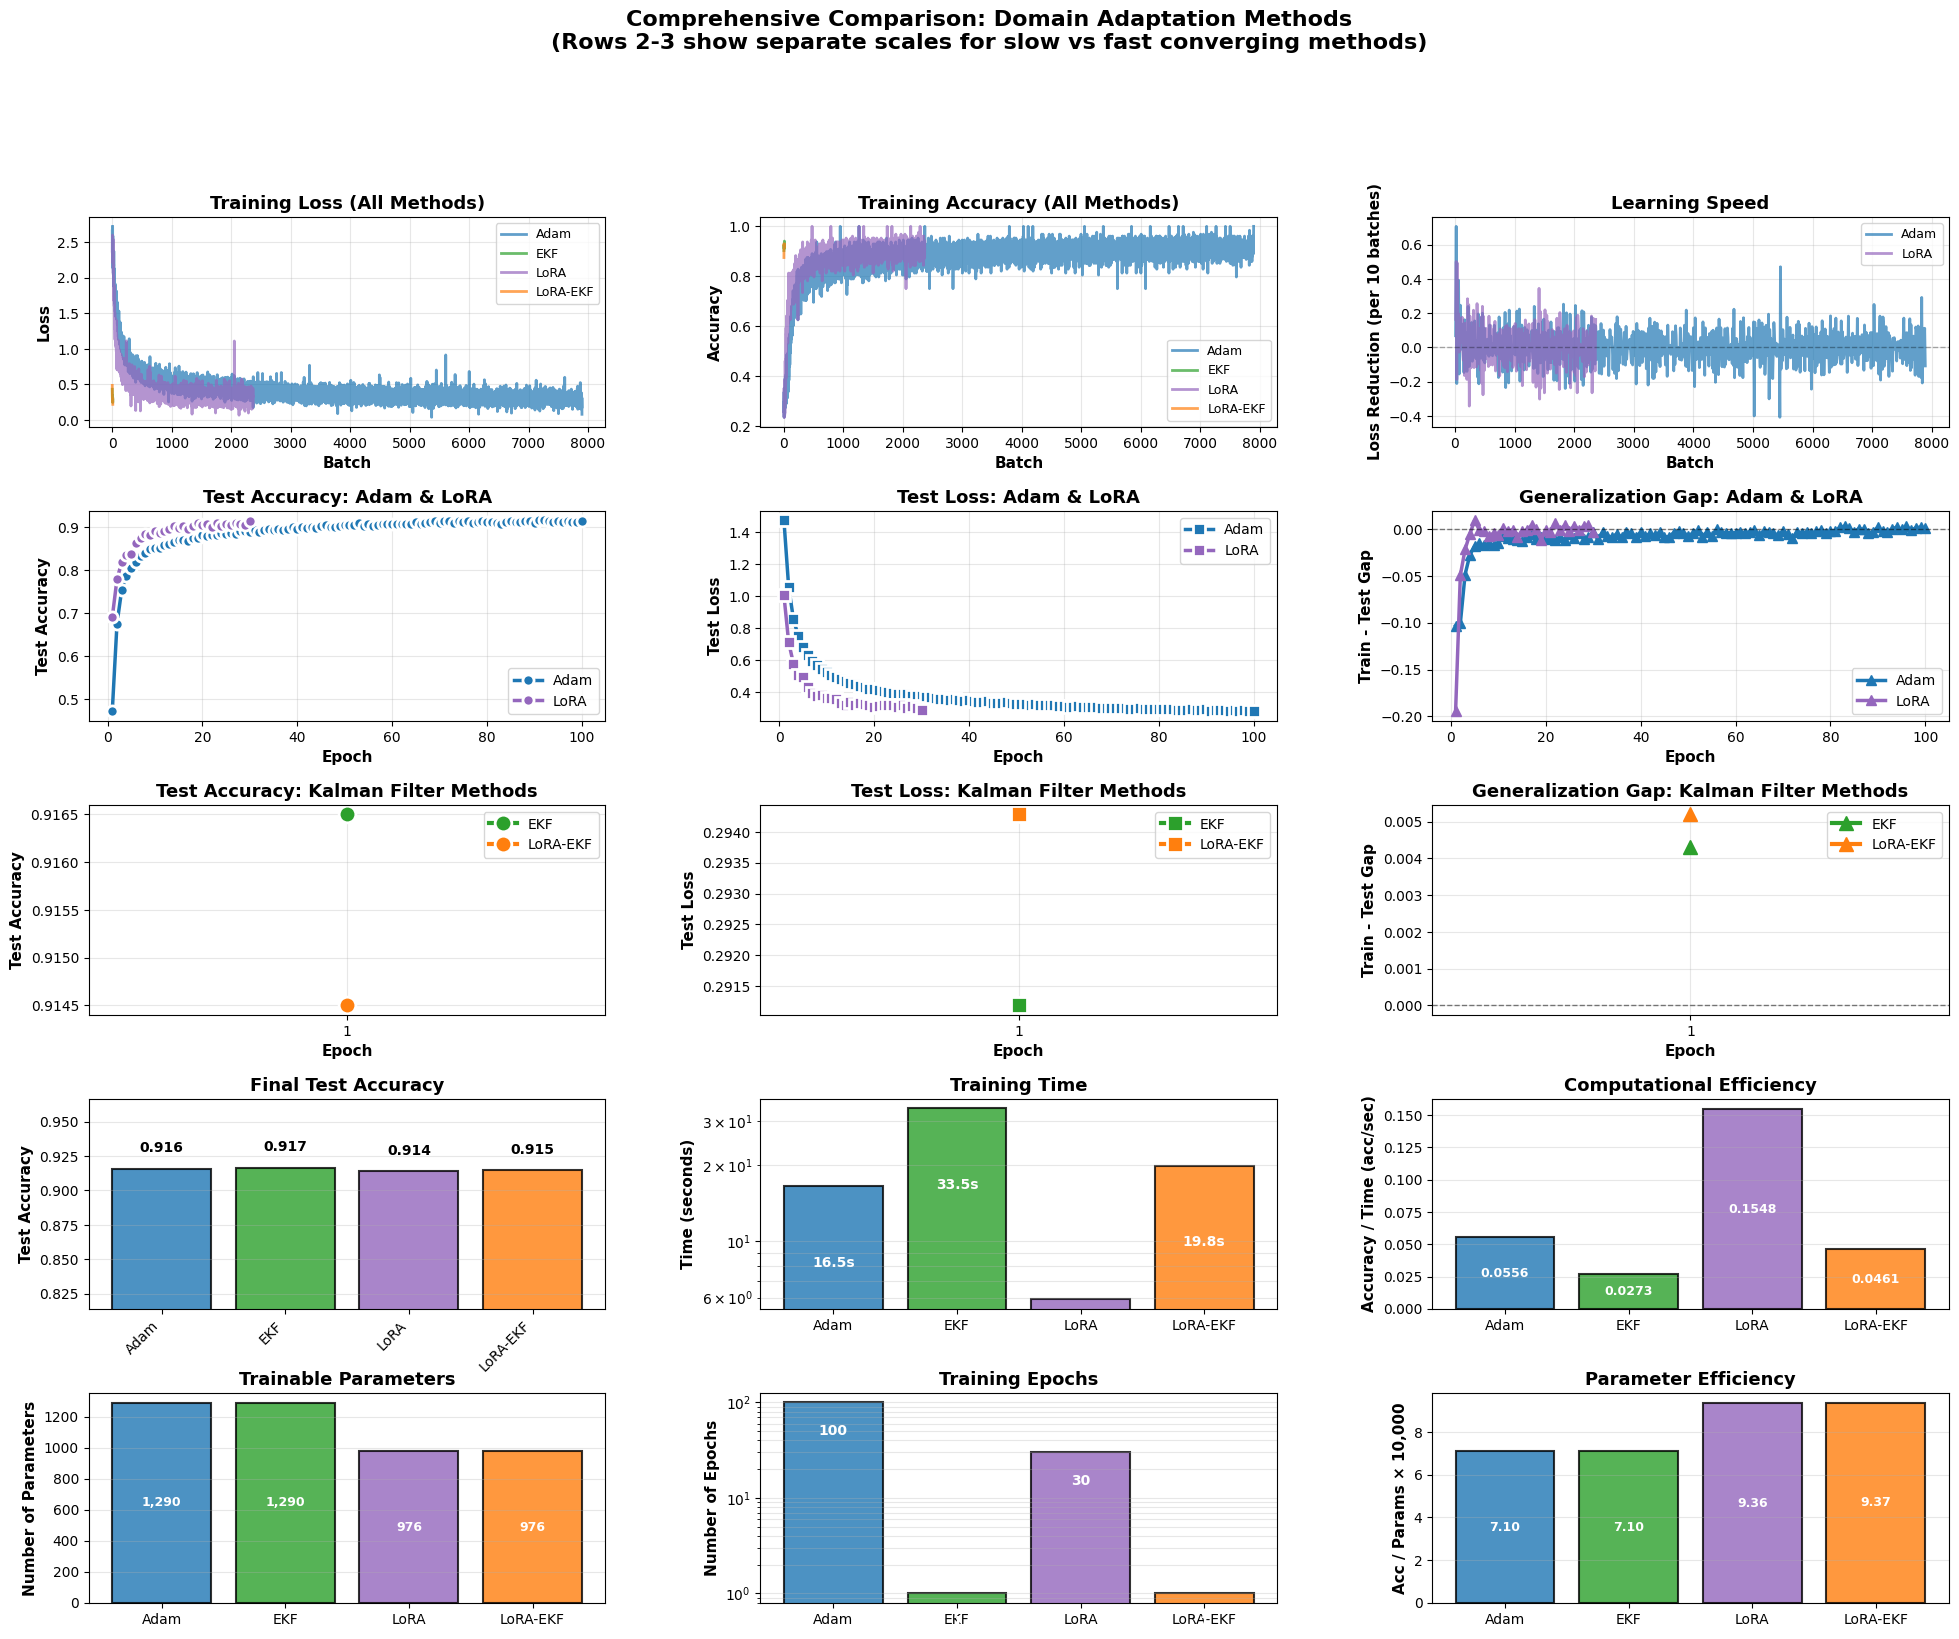

In [16]:
results = {
    'adam': adam_results,
    'ekf': ekf_results,
    'lora': lora_results,
    'lora_ekf': lora_ekf_results
}

def get_param_count(method_name):
    """Extract parameter count based on method"""
    if method_name == 'adam':
        output_state = nnx.state(adam_results['model'].output, nnx.Param)
        flat_params, _ = ravel_pytree(output_state)
        return flat_params.size
    elif method_name == 'ekf':
        output_state = nnx.state(ekf_results['model'].output, nnx.Param)
        flat_params, _ = ravel_pytree(output_state)
        return flat_params.size
    elif method_name == 'lora':
        lora_model = lora_results['model']
        output_state = nnx.state(lora_model.output, nnx.Param)
        
        trainable_dict = {}
        if 'lora' in output_state:
            trainable_dict['lora'] = output_state['lora']
        if 'bias' in output_state:
            trainable_dict['bias'] = output_state['bias']
        
        flat_params, _ = ravel_pytree(trainable_dict)
        return flat_params.size
    elif method_name == 'lora_ekf':
        lora_ekf_model = lora_ekf_results['model']
        output_state = nnx.state(lora_ekf_model.output, nnx.Param)
        
        trainable_dict = {}
        if 'lora' in output_state:
            trainable_dict['lora'] = output_state['lora']
        if 'bias' in output_state:
            trainable_dict['bias'] = output_state['bias']
        
        flat_params, _ = ravel_pytree(trainable_dict)
        return flat_params.size
    return 0

param_counts = {
    'adam': get_param_count('adam'),
    'ekf': get_param_count('ekf'),
    'lora': get_param_count('lora'),
    'lora_ekf': get_param_count('lora_ekf')
}

for method, count in param_counts.items():
    results[method]['n_params'] = count
    print(f"{method.upper()}: {count:,} trainable parameters")

def plot_comprehensive_results_v2(results):
    fig = plt.figure(figsize=(24, 18))
    gs = fig.add_gridspec(5, 3, hspace=0.4, wspace=0.3)

    methods = ['adam', 'ekf', 'lora', 'lora_ekf']
    fast_methods = ['ekf', 'lora_ekf']
    slow_methods = ['adam', 'lora']

    colors = {
        'adam': '#1f77b4', 'ekf': '#2ca02c',
        'lora': '#9467bd', 'lora_ekf': '#ff7f0e'
    }
    labels = {
        'adam': 'Adam', 'ekf': 'EKF',
        'lora': 'LoRA', 'lora_ekf': 'LoRA-EKF'
    }

    ax = fig.add_subplot(gs[0, 0])
    for method in methods:
        ax.plot(results[method]['losses'], color=colors[method],
                label=labels[method], linewidth=2, alpha=0.7)
    ax.set_xlabel('Batch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=11, fontweight='bold')
    ax.set_title('Training Loss (All Methods)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = fig.add_subplot(gs[0, 1])
    for method in methods:
        ax.plot(results[method]['accs'], color=colors[method],
                label=labels[method], linewidth=2, alpha=0.7)
    ax.set_xlabel('Batch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Training Accuracy (All Methods)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = fig.add_subplot(gs[0, 2])
    for method in methods:
        losses = np.array(results[method]['losses'])
        window = 10
        if len(losses) > window:
            loss_reduction = []
            for i in range(window, len(losses), window):
                reduction = losses[i-window] - losses[i]
                loss_reduction.append(reduction)
            x_vals = np.arange(window, len(losses), window)
            ax.plot(x_vals, loss_reduction, color=colors[method],
                    label=labels[method], linewidth=2, alpha=0.7)
    ax.set_xlabel('Batch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Loss Reduction (per 10 batches)', fontsize=11, fontweight='bold')
    ax.set_title('Learning Speed', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.3)

    ax = fig.add_subplot(gs[1, 0])
    for method in slow_methods:
        method_epochs = range(1, len(results[method]['test_accs_per_epoch']) + 1)
        ax.plot(method_epochs, results[method]['test_accs_per_epoch'],
                color=colors[method], label=labels[method],
                linewidth=2.5, marker='o', markersize=8, markeredgewidth=2,
                markeredgecolor='white')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Test Accuracy: Adam & LoRA', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    ax = fig.add_subplot(gs[1, 1])
    for method in slow_methods:
        method_epochs = range(1, len(results[method]['test_losses_per_epoch']) + 1)
        ax.plot(method_epochs, results[method]['test_losses_per_epoch'],
                color=colors[method], label=labels[method],
                linewidth=2.5, marker='s', markersize=8, markeredgewidth=2,
                markeredgecolor='white')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Test Loss', fontsize=11, fontweight='bold')
    ax.set_title('Test Loss: Adam & LoRA', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    ax = fig.add_subplot(gs[1, 2])
    for method in slow_methods:
        method_epochs = range(1, len(results[method]['test_accs_per_epoch']) + 1)
        n_epochs = len(results[method]['test_accs_per_epoch'])
        n_batches = len(results[method]['accs']) // n_epochs
        train_acc_per_epoch = [
            np.mean(results[method]['accs'][i*n_batches:(i+1)*n_batches])
            for i in range(n_epochs)
        ]
        gap = np.array(train_acc_per_epoch) - np.array(results[method]['test_accs_per_epoch'])
        ax.plot(method_epochs, gap, color=colors[method], label=labels[method],
                linewidth=2.5, marker='^', markersize=7)
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Train - Test Gap', fontsize=11, fontweight='bold')
    ax.set_title('Generalization Gap: Adam & LoRA', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)

    ax = fig.add_subplot(gs[2, 0])
    for method in fast_methods:
        method_epochs = range(1, len(results[method]['test_accs_per_epoch']) + 1)
        ax.plot(method_epochs, results[method]['test_accs_per_epoch'],
                color=colors[method], label=labels[method],
                linewidth=3, marker='o', markersize=12, markeredgewidth=2,
                markeredgecolor='white')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Test Accuracy: Kalman Filter Methods', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, max(len(results[m]['test_accs_per_epoch']) for m in fast_methods) + 1))

    ax = fig.add_subplot(gs[2, 1])
    for method in fast_methods:
        method_epochs = range(1, len(results[method]['test_losses_per_epoch']) + 1)
        ax.plot(method_epochs, results[method]['test_losses_per_epoch'],
                color=colors[method], label=labels[method],
                linewidth=3, marker='s', markersize=12, markeredgewidth=2,
                markeredgecolor='white')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Test Loss', fontsize=11, fontweight='bold')
    ax.set_title('Test Loss: Kalman Filter Methods', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, max(len(results[m]['test_losses_per_epoch']) for m in fast_methods) + 1))

    ax = fig.add_subplot(gs[2, 2])
    for method in fast_methods:
        method_epochs = range(1, len(results[method]['test_accs_per_epoch']) + 1)
        n_epochs = len(results[method]['test_accs_per_epoch'])
        n_batches = len(results[method]['accs']) // n_epochs
        train_acc_per_epoch = [
            np.mean(results[method]['accs'][i*n_batches:(i+1)*n_batches])
            for i in range(n_epochs)
        ]
        gap = np.array(train_acc_per_epoch) - np.array(results[method]['test_accs_per_epoch'])
        ax.plot(method_epochs, gap, color=colors[method], label=labels[method],
                linewidth=3, marker='^', markersize=10)
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Train - Test Gap', fontsize=11, fontweight='bold')
    ax.set_title('Generalization Gap: Kalman Filter Methods', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xticks(range(1, max(len(results[m]['test_accs_per_epoch']) for m in fast_methods) + 1))

    ax = fig.add_subplot(gs[3, 0])
    test_accs = [results[m]['test_acc'] for m in methods]
    method_labels = [labels[m] for m in methods]
    bars = ax.bar(method_labels, test_accs, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Final Test Accuracy', fontsize=13, fontweight='bold')
    ax.set_ylim([min(test_accs) - 0.1, max(test_accs) + 0.05])
    for i, (v, bar) in enumerate(zip(test_accs, bars)):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    ax = fig.add_subplot(gs[3, 1])
    times = [results[m]['time'] for m in methods]
    bars = ax.bar(range(len(methods)), times, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title('Training Time', fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels([labels[m] for m in methods], fontsize=10)
    
    for i, (v, bar) in enumerate(zip(times, bars)):
        y_pos = v / 2
        ax.text(i, y_pos, f'{v:.1f}s', ha='center', va='center',
                fontweight='bold', fontsize=10, color='white')
    ax.grid(True, alpha=0.3, axis='y', which='both')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

    ax = fig.add_subplot(gs[3, 2])
    efficiency = [results[m]['test_acc'] / results[m]['time'] for m in methods]
    bars = ax.bar(range(len(methods)), efficiency, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Accuracy / Time (acc/sec)', fontsize=11, fontweight='bold')
    ax.set_title('Computational Efficiency', fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels([labels[m] for m in methods], fontsize=10)
    
    for i, (v, bar) in enumerate(zip(efficiency, bars)):
        y_pos = v / 2
        ax.text(i, y_pos, f'{v:.4f}', ha='center', va='center',
                fontweight='bold', fontsize=9, color='white')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

    ax = fig.add_subplot(gs[4, 0])
    n_params = [results[m]['n_params'] for m in methods]
    bars = ax.bar(range(len(methods)), n_params, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Number of Parameters', fontsize=11, fontweight='bold')
    ax.set_title('Trainable Parameters', fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels([labels[m] for m in methods], fontsize=10)
    
    for i, (v, bar) in enumerate(zip(n_params, bars)):
        y_pos = v / 2
        ax.text(i, y_pos, f'{v:,}', ha='center', va='center',
                fontweight='bold', fontsize=9, color='white')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

    ax = fig.add_subplot(gs[4, 1])
    n_epochs = [len(results[m]['test_accs_per_epoch']) for m in methods]
    bars = ax.bar(range(len(methods)), n_epochs, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Number of Epochs', fontsize=11, fontweight='bold')
    ax.set_title('Training Epochs', fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels([labels[m] for m in methods], fontsize=10)
    
    for i, (v, bar) in enumerate(zip(n_epochs, bars)):
        y_pos = v / 2
        ax.text(i, y_pos, f'{v}', ha='center', va='center',
                fontweight='bold', fontsize=10, color='white')
    ax.grid(True, alpha=0.3, axis='y', which='both')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

    ax = fig.add_subplot(gs[4, 2])
    param_efficiency = [results[m]['test_acc'] / results[m]['n_params'] * 10000 for m in methods]
    bars = ax.bar(range(len(methods)), param_efficiency, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Acc / Params × 10,000', fontsize=11, fontweight='bold')
    ax.set_title('Parameter Efficiency', fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels([labels[m] for m in methods], fontsize=10)
    
    for i, (v, bar) in enumerate(zip(param_efficiency, bars)):
        y_pos = v / 2
        ax.text(i, y_pos, f'{v:.2f}', ha='center', va='center',
                fontweight='bold', fontsize=9, color='white')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

    plt.suptitle('Comprehensive Comparison: Domain Adaptation Methods\n' +
                 '(Rows 2-3 show separate scales for slow vs fast converging methods)',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('/mnt/user-data/outputs/comprehensive_results_v2.png',
                dpi=300, bbox_inches='tight')
    print("\nComprehensive results v2 saved!")
    plt.show()

plot_comprehensive_results_v2(results)

### Benchmarking

In [17]:

multi_seed_results = {
    'adam': {'test_accs': [], 'test_losses': [], 'times': []},
    'ekf': {'test_accs': [], 'test_losses': [], 'times': []},
    'lora': {'test_accs': [], 'test_losses': [], 'times': []},
    'lora_ekf': {'test_accs': [], 'test_losses': [], 'times': []}
}

N_SEEDS = 5
BASE_SEED = 42

config.print_batch_metrics = False
config.verify_covariance = False

In [18]:
# ADAM - MULTI-SEED EVALUATION

print("\n" + "="*80)
print("ADAM - RUNNING 5-SEED EVALUATION")
print("="*80)

for seed_idx in range(N_SEEDS):
    current_seed = BASE_SEED + seed_idx * 100
    print(f"  Seed {seed_idx + 1}/{N_SEEDS} (seed={current_seed})...", end=" ", flush=True)

    # Load data
    config.seed = current_seed
    X_train_s, y_train_s, X_test_s, y_test_s = load_mnist()
    X_train_shifted_s = apply_domain_shift(X_train_s, shift_type=config.shift_type,
                                           rotation_angle=config.rotation_angle,
                                           contrast=config.contrast,
                                           brightness=config.brightness)
    X_test_shifted_s = apply_domain_shift(X_test_s, shift_type=config.shift_type,
                                          rotation_angle=config.rotation_angle,
                                          contrast=config.contrast,
                                          brightness=config.brightness)

    # Pretrain
    rng = nnx.Rngs(current_seed)
    model = MLP(config.hidden_sizes, config.num_classes, rng)
    state = create_train_state(model, config.pretrain_lr)

    n_batches = int(np.ceil(len(X_train_s) / config.batch_size))
    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + current_seed)
        perm = random.permutation(key, len(X_train_s))
        X_shuffled = X_train_s[perm]
        y_shuffled = y_train_s[perm]
        for i in range(n_batches):
            start_idx = i * config.batch_size
            end_idx = min((i + 1) * config.batch_size, len(X_train_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            state, _, _ = pretrain_step(state, (batch_x, batch_y))

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    pretrained_model_s = nnx.merge(graphdef, state.params, other_states)

    # Train ADAM
    adam_model_s = nnx.clone(pretrained_model_s)
    adam_state_s = create_output_only_train_state(adam_model_s, config.finetune_lr)

    start_time = time.time()
    n_batches_per_epoch = int(np.ceil(len(X_train_shifted_s) / config.batch_size))

    for epoch in range(config.adam_epochs):
        key = random.PRNGKey(epoch + current_seed + 1000)
        perm = random.permutation(key, len(X_train_shifted_s))
        X_shuffled = X_train_shifted_s[perm]
        y_shuffled = y_train_s[perm]

        for batch_idx in range(n_batches_per_epoch):
            start_idx = batch_idx * config.batch_size
            end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            adam_state_s, _, _ = finetune_step(adam_state_s, (batch_x, batch_y))

    adam_time = time.time() - start_time

    # Evaluate
    test_logits = adam_state_s.apply_fn(adam_state_s.params, X_test_shifted_s, training=False)
    adam_acc = float(compute_accuracy(test_logits, y_test_s))
    adam_loss = float(cross_entropy_loss(test_logits, y_test_s))

    multi_seed_results['adam']['test_accs'].append(adam_acc)
    multi_seed_results['adam']['test_losses'].append(adam_loss)
    multi_seed_results['adam']['times'].append(adam_time)

    print(f"Acc={adam_acc:.4f}, Loss={adam_loss:.4f}, Time={adam_time:.2f}s")

print(f"ADAM Mean: Acc={np.mean(multi_seed_results['adam']['test_accs']):.4f} ± {np.std(multi_seed_results['adam']['test_accs']):.4f}")


ADAM - RUNNING 5-SEED EVALUATION
  Seed 1/5 (seed=42)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
Acc=0.8840, Loss=0.4564, Time=1.75s
  Seed 2/5 (seed=142)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
Acc=0.8860, Loss=0.4381, Time=1.76s
  Seed 3/5 (seed=242)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
Acc=0.8800, Loss=0.4577, Time=1.76s
  Seed 4/5 (seed=342)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
Acc=0.8850, Loss=0.4664, Time=1.74s
  Seed 5/5 (seed=442)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
Acc=0.8825, Loss=0.4444, Time=1.73s
ADAM Mean: Acc=0.8835 ± 0.0021


In [19]:
# EKF - MULTI-SEED EVALUATION

print("\n" + "="*80)
print("EKF - RUNNING 5-SEED EVALUATION")
print("="*80)

for seed_idx in range(N_SEEDS):
    current_seed = BASE_SEED + seed_idx * 100
    print(f"  Seed {seed_idx + 1}/{N_SEEDS} (seed={current_seed})...", end=" ", flush=True)

    # Load data
    config.seed = current_seed
    X_train_s, y_train_s, X_test_s, y_test_s = load_mnist()
    X_train_shifted_s = apply_domain_shift(X_train_s, shift_type=config.shift_type,
                                           rotation_angle=config.rotation_angle,
                                           contrast=config.contrast,
                                           brightness=config.brightness)
    X_test_shifted_s = apply_domain_shift(X_test_s, shift_type=config.shift_type,
                                          rotation_angle=config.rotation_angle,
                                          contrast=config.contrast,
                                          brightness=config.brightness)

    # Pretrain
    rng = nnx.Rngs(current_seed)
    model = MLP(config.hidden_sizes, config.num_classes, rng)
    state = create_train_state(model, config.pretrain_lr)

    config.batch_size = 1000
    n_batches = int(np.ceil(len(X_train_s) / config.batch_size))
    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + current_seed)
        perm = random.permutation(key, len(X_train_s))
        X_shuffled = X_train_s[perm]
        y_shuffled = y_train_s[perm]
        for i in range(n_batches):
            start_idx = i * config.batch_size
            end_idx = min((i + 1) * config.batch_size, len(X_train_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            state, _, _ = pretrain_step(state, (batch_x, batch_y))

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    pretrained_model_s = nnx.merge(graphdef, state.params, other_states)

    # Train EKF
    ekf_model_s = nnx.clone(pretrained_model_s)
    P_ekf_s = None

    start_time = time.time()
    n_batches_per_epoch = int(np.ceil(len(X_train_shifted_s) / config.batch_size))

    for epoch in range(config.ekf_epochs):
        key = random.PRNGKey(epoch + current_seed + 2000)
        perm = random.permutation(key, len(X_train_shifted_s))
        X_shuffled = X_train_shifted_s[perm]
        y_shuffled = y_train_s[perm]

        for batch_idx in range(n_batches_per_epoch):
            start_idx = batch_idx * config.batch_size
            end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            ekf_model_s, P_ekf_s = ekf_update(ekf_model_s, batch_x, batch_y, P_ekf_s, use_full_cov=True)

    ekf_time = time.time() - start_time

    # Evaluate
    test_logits = ekf_model_s(X_test_shifted_s, training=False)
    ekf_acc = float(compute_accuracy(test_logits, y_test_s))
    ekf_loss = float(cross_entropy_loss(test_logits, y_test_s))

    multi_seed_results['ekf']['test_accs'].append(ekf_acc)
    multi_seed_results['ekf']['test_losses'].append(ekf_loss)
    multi_seed_results['ekf']['times'].append(ekf_time)

    print(f"Acc={ekf_acc:.4f}, Loss={ekf_loss:.4f}, Time={ekf_time:.2f}s")

print(f"EKF Mean: Acc={np.mean(multi_seed_results['ekf']['test_accs']):.4f} ± {np.std(multi_seed_results['ekf']['test_accs']):.4f}")


EKF - RUNNING 5-SEED EVALUATION
  Seed 1/5 (seed=42)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  [EKF] Initializing covariance: P0 = 0.1 × I (1290×1290)
Acc=0.9045, Loss=0.3516, Time=30.11s
  Seed 2/5 (seed=142)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  [EKF] Initializing covariance: P0 = 0.1 × I (1290×1290)
Acc=0.9075, Loss=0.3456, Time=30.13s
  Seed 3/5 (seed=242)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  [EKF] Initializing covariance: P0 = 0.1 × I (1290×1290)
Acc=0.8990, Loss=0.3693, Time=30.63s
  Seed 4/5 (seed=342)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  [EKF] Initializing covariance: P0 = 0.1 × I (1290×1290)
Acc=0.9070, Loss=0.3742, Time=30.19s
  Seed 5/5 (seed=442)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  [EKF] Initializing covariance: P0 = 

In [20]:
# LORA - MULTI-SEED EVALUATION

print("\n" + "="*80)
print("LORA - RUNNING 5-SEED EVALUATION")
print("="*80)

for seed_idx in range(N_SEEDS):
    current_seed = BASE_SEED + seed_idx * 100
    print(f"  Seed {seed_idx + 1}/{N_SEEDS} (seed={current_seed})...", end=" ", flush=True)

    # Load data
    config.seed = current_seed
    X_train_s, y_train_s, X_test_s, y_test_s = load_mnist()
    X_train_shifted_s = apply_domain_shift(X_train_s, shift_type=config.shift_type,
                                           rotation_angle=config.rotation_angle,
                                           contrast=config.contrast,
                                           brightness=config.brightness)
    X_test_shifted_s = apply_domain_shift(X_test_s, shift_type=config.shift_type,
                                          rotation_angle=config.rotation_angle,
                                          contrast=config.contrast,
                                          brightness=config.brightness)

    # Pretrain
    rng = nnx.Rngs(current_seed)
    model = MLP(config.hidden_sizes, config.num_classes, rng)
    state = create_train_state(model, config.pretrain_lr)
    config.batch_size = 128
    n_batches = int(np.ceil(len(X_train_s) / config.batch_size))
    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + current_seed)
        perm = random.permutation(key, len(X_train_s))
        X_shuffled = X_train_s[perm]
        y_shuffled = y_train_s[perm]
        for i in range(n_batches):
            start_idx = i * config.batch_size
            end_idx = min((i + 1) * config.batch_size, len(X_train_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            state, _, _ = pretrain_step(state, (batch_x, batch_y))

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    pretrained_model_s = nnx.merge(graphdef, state.params, other_states)

    # Train LoRA
    lora_model_s = create_lora_model(pretrained_model_s, config.lora_rank, config.lora_alpha)
    graphdef_lora, trainable_params_s, frozen_params_s = nnx.split(lora_model_s, is_lora_trainable, ...)
    tx = optax.adam(config.lora_finetune_lr)
    opt_state_s = tx.init(trainable_params_s)

    start_time = time.time()
    n_batches_per_epoch = int(np.ceil(len(X_train_shifted_s) / config.batch_size))

    for epoch in range(config.lora_epochs):
        key = random.PRNGKey(epoch + current_seed + 4000)
        perm = random.permutation(key, len(X_train_shifted_s))
        X_shuffled = X_train_shifted_s[perm]
        y_shuffled = y_train_s[perm]

        for batch_idx in range(n_batches_per_epoch):
            start_idx = batch_idx * config.batch_size
            end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            trainable_params_s, opt_state_s, _, _ = lora_train_step_jitted(
                graphdef_lora, trainable_params_s, frozen_params_s, opt_state_s, (batch_x, batch_y)
            )

    lora_time = time.time() - start_time

    # Update and evaluate
    updated_state = nnx.State.merge(trainable_params_s, frozen_params_s)
    nnx.update(lora_model_s, updated_state)

    test_logits = lora_model_s(X_test_shifted_s, training=False)
    lora_acc = float(compute_accuracy(test_logits, y_test_s))
    lora_loss = float(cross_entropy_loss(test_logits, y_test_s))

    multi_seed_results['lora']['test_accs'].append(lora_acc)
    multi_seed_results['lora']['test_losses'].append(lora_loss)
    multi_seed_results['lora']['times'].append(lora_time)

    print(f"Acc={lora_acc:.4f}, Loss={lora_loss:.4f}, Time={lora_time:.2f}s")

print(f"LoRA Mean: Acc={np.mean(multi_seed_results['lora']['test_accs']):.4f} ± {np.std(multi_seed_results['lora']['test_accs']):.4f}")


LORA - RUNNING 5-SEED EVALUATION
  Seed 1/5 (seed=42)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 14.0/7 = 2.0000
Acc=0.9140, Loss=0.2867, Time=2.52s
  Seed 2/5 (seed=142)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 14.0/7 = 2.0000
Acc=0.8965, Loss=0.3538, Time=2.57s
  Seed 3/5 (seed=242)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 14.0/7 = 2.0000
Acc=0.8885, Loss=0.3600, Time=2.58s
  Seed 4/5 (seed=342)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 14.0/7 = 2.0000
Acc=0.9170, Loss=0.3239, Time=2.58s
  Seed 5/5 (seed=442)... Data l

In [21]:
# LORA-EKF: Full EKF on LoRA Parameters

def lora_ekf_update(model, X_batch, y_batch, P_previous=None, step=0):

    output_layer = model.output

    output_state = nnx.state(output_layer, nnx.Param)

    trainable_dict = {}

    if 'lora' in output_state:
        trainable_dict['lora'] = output_state['lora']

    if 'bias' in output_state:
        trainable_dict['bias'] = output_state['bias']

    flat_params, unflatten_fn = ravel_pytree(trainable_dict)
    state_dim = flat_params.size

    #if step == 0: # need to comment this printing as we are not handling step var in the training loop
    #    print(f"  [LoRA-EKF] Trainable params: {state_dim} parameters")
    #    print(f"  [LoRA-EKF] Keys: {list(trainable_dict.keys())}")

    frozen_kernel = output_state['kernel']

    def forward_fn(params_flat, x):
        params = unflatten_fn(params_flat)

        temp_state = {'kernel': frozen_kernel}
        temp_state.update(params)

        output_graphdef, _, other_states = nnx.split(output_layer, nnx.Param, ...)
        output_layer_temp = nnx.merge(output_graphdef, temp_state, other_states)

        features = model.extract_features(x)
        logits = output_layer_temp(features)

        return jax.nn.softmax(logits)

    initial_mean = flat_params

    if P_previous is None:
        initial_covariance = jnp.eye(state_dim) * config.prior_variance
        print(f"  [LoRA-EKF] Initializing covariance: P0 = {config.prior_variance} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_previous
        if step % 50 == 0:
            verify_covariance_matrix(P_previous, "P_lora_prev", step)

    dynamics_function = lambda w, x: w
    dynamics_covariance = jnp.eye(state_dim) * config.dynamics_sigma

    def emission_mean_function(w, x):
        return forward_fn(w, x)

    def emission_cov_function(w, x):
        probs = emission_mean_function(w, x)
        return jnp.diag(probs * (1 - probs)) + config.observation_noise * jnp.eye(config.num_classes)

    params = ParamsGGSSM(
        initial_mean=initial_mean,
        initial_covariance=initial_covariance,
        dynamics_function=dynamics_function,
        dynamics_covariance=dynamics_covariance,
        emission_mean_function=emission_mean_function,
        emission_cov_function=emission_cov_function
    )

    emissions = jax.nn.one_hot(y_batch, config.num_classes)
    inputs = X_batch

    ekf_post = conditional_moments_gaussian_filter(
        params,
        EKFIntegrals(),
        emissions,
        inputs
    )

    updated_params_flat = ekf_post.filtered_means[-1]
    updated_covariance = ekf_post.filtered_covariances[-1]

    if step % 50 == 0:
        verify_covariance_matrix(updated_covariance, "P_lora_updated", step)
        compare_covariances(P_previous, updated_covariance, "P_LoRA", step)

    updated_params = unflatten_fn(updated_params_flat)

    nnx.update(output_layer, updated_params)

    return model, updated_covariance

print("LoRA-EKF update function defined")

LoRA-EKF update function defined


In [22]:
# LORA-EKF - MULTI-SEED EVALUATION

print("\n" + "="*80)
print("LORA-EKF - RUNNING 5-SEED EVALUATION")
print("="*80)

for seed_idx in range(N_SEEDS):
    current_seed = BASE_SEED + seed_idx * 100
    print(f"  Seed {seed_idx + 1}/{N_SEEDS} (seed={current_seed})...", end=" ", flush=True)

    # Load data
    config.seed = current_seed
    X_train_s, y_train_s, X_test_s, y_test_s = load_mnist()
    X_train_shifted_s = apply_domain_shift(X_train_s, shift_type=config.shift_type,
                                           rotation_angle=config.rotation_angle,
                                           contrast=config.contrast,
                                           brightness=config.brightness)
    X_test_shifted_s = apply_domain_shift(X_test_s, shift_type=config.shift_type,
                                          rotation_angle=config.rotation_angle,
                                          contrast=config.contrast,
                                          brightness=config.brightness)

    # Pretrain
    rng = nnx.Rngs(current_seed)
    model = MLP(config.hidden_sizes, config.num_classes, rng)
    state = create_train_state(model, config.pretrain_lr)

    config.batch_size = 1000
    n_batches = int(np.ceil(len(X_train_s) / config.batch_size))
    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + current_seed)
        perm = random.permutation(key, len(X_train_s))
        X_shuffled = X_train_s[perm]
        y_shuffled = y_train_s[perm]
        for i in range(n_batches):
            start_idx = i * config.batch_size
            end_idx = min((i + 1) * config.batch_size, len(X_train_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            state, _, _ = pretrain_step(state, (batch_x, batch_y))

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    pretrained_model_s = nnx.merge(graphdef, state.params, other_states)

    # Train LoRA-EKF
    lora_ekf_model_s = create_lora_model(pretrained_model_s, config.lora_rank, config.lora_alpha)
    P_lora_ekf_s = None

    start_time = time.time()
    n_batches_per_epoch = int(np.ceil(len(X_train_shifted_s) / config.batch_size))

    for epoch in range(config.lora_ekf_epochs):
        key = random.PRNGKey(epoch + current_seed + 6000)
        perm = random.permutation(key, len(X_train_shifted_s))
        X_shuffled = X_train_shifted_s[perm]
        y_shuffled = y_train_s[perm]

        for batch_idx in range(n_batches_per_epoch):
            start_idx = batch_idx * config.batch_size
            end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            lora_ekf_model_s, P_lora_ekf_s = lora_ekf_update(lora_ekf_model_s, batch_x, batch_y, P_lora_ekf_s)

    lora_ekf_time = time.time() - start_time

    # Evaluate
    test_logits = lora_ekf_model_s(X_test_shifted_s, training=False)
    lora_ekf_acc = float(compute_accuracy(test_logits, y_test_s))
    lora_ekf_loss = float(cross_entropy_loss(test_logits, y_test_s))

    multi_seed_results['lora_ekf']['test_accs'].append(lora_ekf_acc)
    multi_seed_results['lora_ekf']['test_losses'].append(lora_ekf_loss)
    multi_seed_results['lora_ekf']['times'].append(lora_ekf_time)

    print(f"Acc={lora_ekf_acc:.4f}, Loss={lora_ekf_loss:.4f}, Time={lora_ekf_time:.2f}s")

print(f"LoRA-EKF Mean: Acc={np.mean(multi_seed_results['lora_ekf']['test_accs']):.4f} ± {np.std(multi_seed_results['lora_ekf']['test_accs']):.4f}")


LORA-EKF - RUNNING 5-SEED EVALUATION
  Seed 1/5 (seed=42)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 14.0/7 = 2.0000
  [LoRA-EKF] Initializing covariance: P0 = 0.1 × I (976×976)
Acc=0.9060, Loss=0.3218, Time=18.54s
  Seed 2/5 (seed=142)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 14.0/7 = 2.0000
  [LoRA-EKF] Initializing covariance: P0 = 0.1 × I (976×976)
Acc=0.8980, Loss=0.3454, Time=19.09s
  Seed 3/5 (seed=242)... Data loaded:
  Train: (10000, 784), dtype=float32
  Test: (2000, 784), dtype=float32
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 14.0/7 = 2.0000
  [LoRA-EKF] Initializing covariance: P0 = 0.1 × I (976×976)
Acc=0.8995, Loss=0.3563, Time=18.49s
  Seed 4/5 (seed=342)... Data loaded:
  Train: (10000, 784), dtype=float32



STATISTICAL ANALYSIS

Method          Test Accuracy                       Test Loss                           Time (s)                      
-------------------------------------------------------------------------------------------------------------------
Adam            0.8835 ± 0.0023 | [0.8806, 0.8864]  0.4526 ± 0.0113 | [0.4386, 0.4666]  1.75 ± 0.01 | [1.73, 1.77]    
EKF             0.9057 ± 0.0043 | [0.9003, 0.9111]  0.3569 ± 0.0140 | [0.3395, 0.3743]  30.25 ± 0.22 | [29.98, 30.52] 
LoRA            0.9048 ± 0.0120 | [0.8899, 0.9197]  0.3294 ± 0.0293 | [0.2931, 0.3658]  2.56 ± 0.03 | [2.53, 2.60]    
LoRA-EKF        0.9025 ± 0.0035 | [0.8981, 0.9069]  0.3431 ± 0.0182 | [0.3205, 0.3656]  18.61 ± 0.27 | [18.28, 18.95] 

Multi-seed results plot saved!


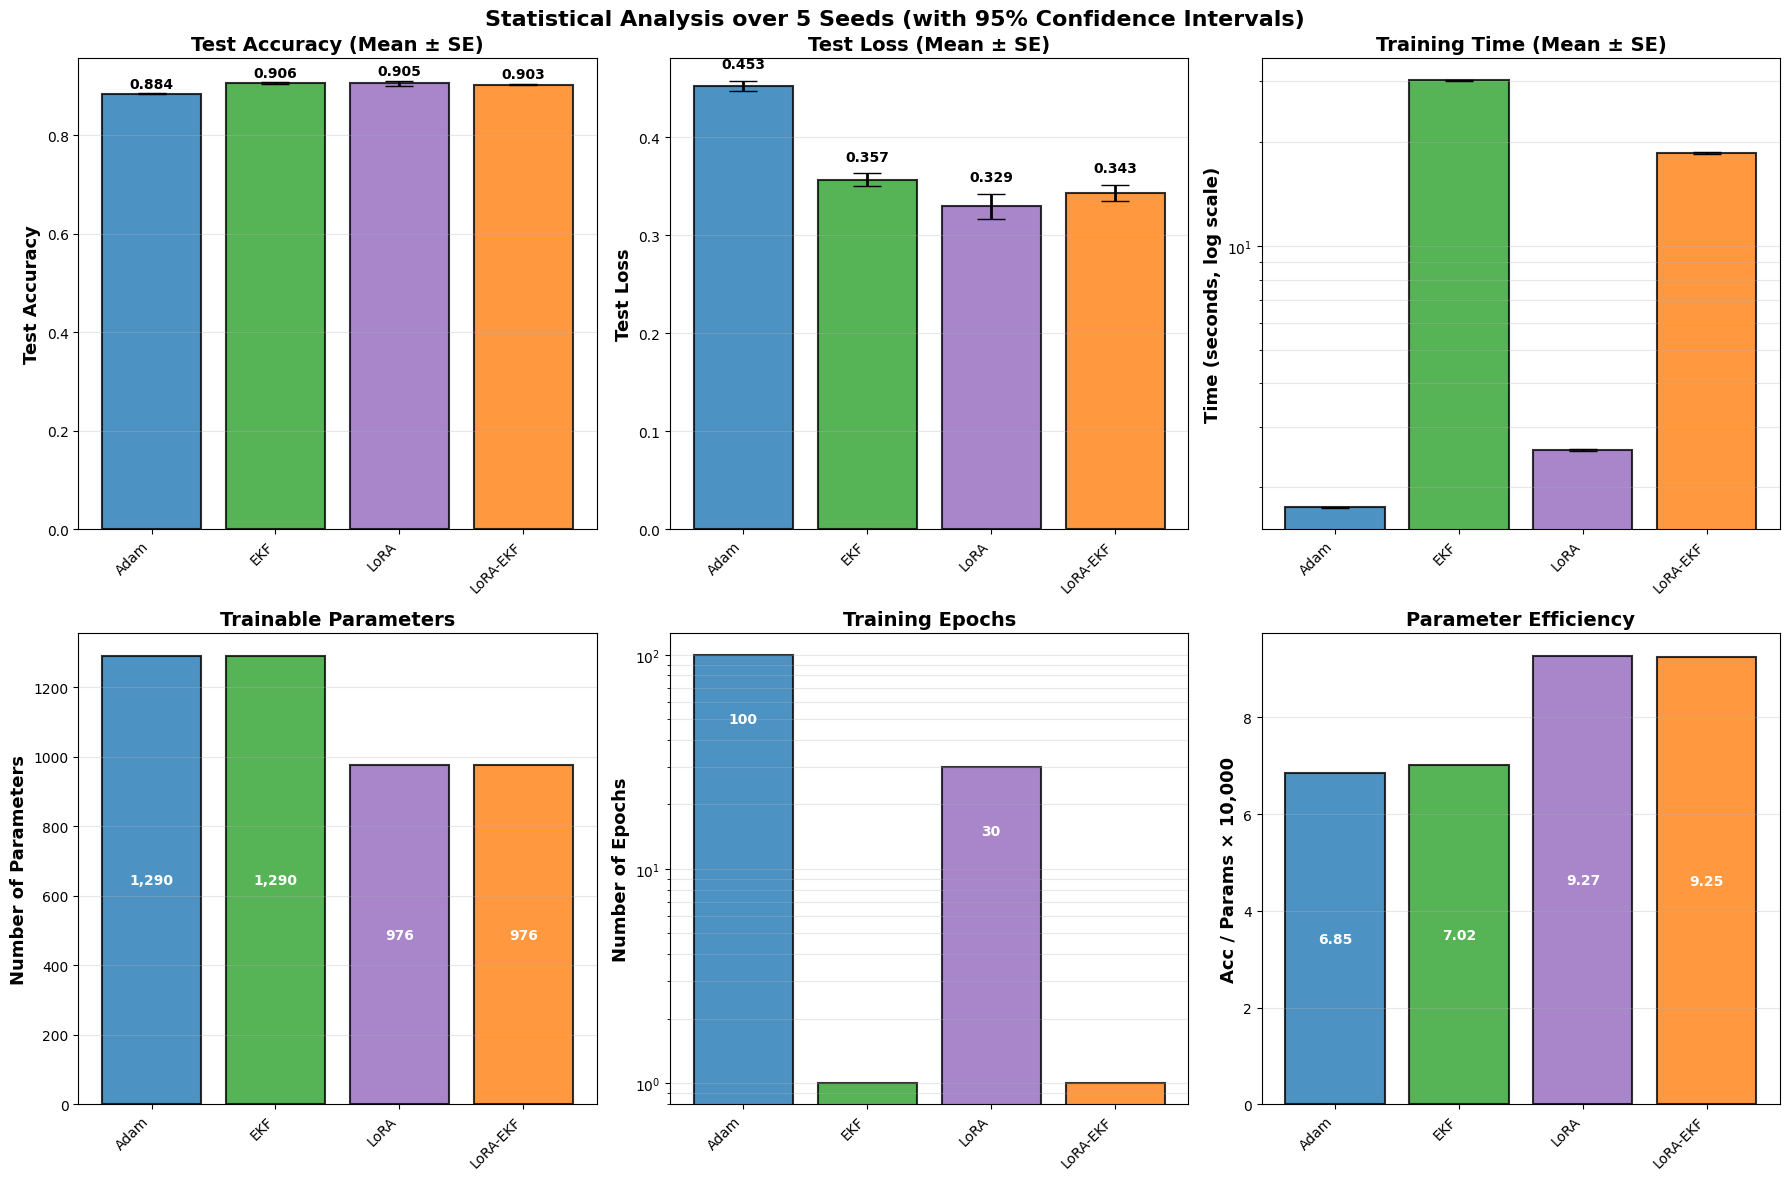


Multi-seed data saved to multi_seed_data.npz


In [23]:
# STATISTICAL ANALYSIS & VISUALIZATION
print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80)

import scipy.stats as stats

def compute_stats(values):
    """Compute mean, std, stderr, and 95% CI"""
    values = np.array(values)
    n = len(values)
    mean = np.mean(values)
    std = np.std(values, ddof=1)
    stderr = std / np.sqrt(n)
    confidence = 0.95
    dof = n - 1
    t_value = stats.t.ppf((1 + confidence) / 2, dof)
    ci_margin = t_value * stderr
    ci_lower = mean - ci_margin
    ci_upper = mean + ci_margin
    
    return {
        'mean': mean,
        'std': std,
        'stderr': stderr,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'ci_margin': ci_margin
    }

statistics = {}
methods = ['adam', 'ekf', 'lora', 'lora_ekf']
method_labels = {
    'adam': 'Adam', 'ekf': 'EKF',
    'lora': 'LoRA', 'lora_ekf': 'LoRA-EKF'
}

for method in methods:
    statistics[method] = {
        'test_acc': compute_stats(multi_seed_results[method]['test_accs']),
        'test_loss': compute_stats(multi_seed_results[method]['test_losses']),
        'time': compute_stats(multi_seed_results[method]['times'])
    }

print(f"\n{'Method':<15} {'Test Accuracy':<35} {'Test Loss':<35} {'Time (s)':<30}")
print("-" * 115)

for method in methods:
    acc_stats = statistics[method]['test_acc']
    loss_stats = statistics[method]['test_loss']
    time_stats = statistics[method]['time']
    
    acc_str = f"{acc_stats['mean']:.4f} ± {acc_stats['std']:.4f} | [{acc_stats['ci_lower']:.4f}, {acc_stats['ci_upper']:.4f}]"
    loss_str = f"{loss_stats['mean']:.4f} ± {loss_stats['std']:.4f} | [{loss_stats['ci_lower']:.4f}, {loss_stats['ci_upper']:.4f}]"
    time_str = f"{time_stats['mean']:.2f} ± {time_stats['std']:.2f} | [{time_stats['ci_lower']:.2f}, {time_stats['ci_upper']:.2f}]"
    
    print(f"{method_labels[method]:<15} {acc_str:<35} {loss_str:<35} {time_str:<30}")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

colors = {
    'adam': '#1f77b4', 'ekf': '#2ca02c',
    'lora': '#9467bd', 'lora_ekf': '#ff7f0e'
}

method_names = [method_labels[m] for m in methods]
x_pos = np.arange(len(methods))

ax = axes[0, 0]
accs_mean = [statistics[m]['test_acc']['mean'] for m in methods]
accs_stderr = [statistics[m]['test_acc']['stderr'] for m in methods]
bars = ax.bar(x_pos, accs_mean, yerr=accs_stderr, capsize=10,
              color=[colors[m] for m in methods], alpha=0.8,
              edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2})
ax.set_ylabel('Test Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Test Accuracy (Mean ± SE)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for i, (m, bar) in enumerate(zip(accs_mean, bars)):
    ax.text(i, m + accs_stderr[i] + 0.005, f'{m:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax = axes[0, 1]
losses_mean = [statistics[m]['test_loss']['mean'] for m in methods]
losses_stderr = [statistics[m]['test_loss']['stderr'] for m in methods]
bars = ax.bar(x_pos, losses_mean, yerr=losses_stderr, capsize=10,
              color=[colors[m] for m in methods], alpha=0.8,
              edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2})
ax.set_ylabel('Test Loss', fontsize=13, fontweight='bold')
ax.set_title('Test Loss (Mean ± SE)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for i, (m, bar) in enumerate(zip(losses_mean, bars)):
    ax.text(i, m + losses_stderr[i] + 0.01, f'{m:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax = axes[0, 2]
times_mean = [statistics[m]['time']['mean'] for m in methods]
times_stderr = [statistics[m]['time']['stderr'] for m in methods]
bars = ax.bar(x_pos, times_mean, yerr=times_stderr, capsize=10,
              color=[colors[m] for m in methods], alpha=0.8,
              edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2})
ax.set_ylabel('Time (seconds, log scale)', fontsize=13, fontweight='bold')
ax.set_title('Training Time (Mean ± SE)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, rotation=45, ha='right')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y', which='both')

ax = axes[1, 0]
n_params_dict = {
    'adam': config.hidden_sizes[0] * config.num_classes + config.num_classes,
    'ekf': config.hidden_sizes[0] * config.num_classes + config.num_classes,
    'lora': config.hidden_sizes[0] * config.lora_rank + config.lora_rank * config.num_classes + config.num_classes,
    'lora_ekf': config.hidden_sizes[0] * config.lora_rank + config.lora_rank * config.num_classes + config.num_classes
}
n_params = [n_params_dict[m] for m in methods]
bars = ax.bar(x_pos, n_params, color=[colors[m] for m in methods], 
              alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Parameters', fontsize=13, fontweight='bold')
ax.set_title('Trainable Parameters', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for i, (v, bar) in enumerate(zip(n_params, bars)):
    y_pos = v / 2
    ax.text(i, y_pos, f'{v:,}', ha='center', va='center',
            fontweight='bold', fontsize=10, color='white')

ax = axes[1, 1]
n_epochs_dict = {
    'adam': config.adam_epochs,
    'ekf': config.ekf_epochs,
    'lora': config.lora_epochs,
    'lora_ekf': config.lora_ekf_epochs
}
n_epochs = [n_epochs_dict[m] for m in methods]
bars = ax.bar(x_pos, n_epochs, color=[colors[m] for m in methods], 
              alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Epochs', fontsize=13, fontweight='bold')
ax.set_title('Training Epochs', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, rotation=45, ha='right')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y', which='both')

for i, (v, bar) in enumerate(zip(n_epochs, bars)):
    y_pos = v / 2
    ax.text(i, y_pos, f'{v}', ha='center', va='center',
            fontweight='bold', fontsize=10, color='white')

ax = axes[1, 2]
param_efficiency = [accs_mean[i] / n_params[i] * 10000 for i in range(len(methods))]
bars = ax.bar(x_pos, param_efficiency, color=[colors[m] for m in methods], 
              alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Acc / Params × 10,000', fontsize=13, fontweight='bold')
ax.set_title('Parameter Efficiency', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for i, (v, bar) in enumerate(zip(param_efficiency, bars)):
    y_pos = v / 2
    ax.text(i, y_pos, f'{v:.2f}', ha='center', va='center',
            fontweight='bold', fontsize=10, color='white')

plt.suptitle(f'Statistical Analysis over {N_SEEDS} Seeds (with 95% Confidence Intervals)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/multi_seed_results.png', dpi=300, bbox_inches='tight')
print("\nMulti-seed results plot saved!")
plt.show()

np.savez('/mnt/user-data/outputs/multi_seed_data.npz',
         **{f'{method}_{metric}': multi_seed_results[method][metric]
            for method in methods
            for metric in ['test_accs', 'test_losses', 'times']})

print("\nMulti-seed data saved to multi_seed_data.npz")